<a href="https://colab.research.google.com/github/Sauryashri822/Data-Analysis-Projects/blob/main/Nifty50_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data collaction


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install yfinance
!pip install ta

In [ ]:
# importing required library .
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import yfinance as yf  # Optional for fresh data
from ta.trend import SMAIndicator, EMAIndicator, MACD  # Technical indicators
from ta.momentum import RSIIndicator
import warnings; warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('NIFTY_50_COMPANIES.csv', parse_dates=['Date']) # Changed to NIFTY_50_COMPANIES.csv
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
print(df.head())  # Check: Adj Close, RSI_14, etc.

            Adj Close       Close        High         Low        Open  \
Date                                                                    
01-01-1998   9.009689   31.600000   31.833332   31.277777   31.722221   
01-01-1998  15.151132   23.243635   23.347424   22.856792   22.932274   
01-01-1998   2.937171    4.831835    4.863281    4.808593    4.862890   
01-01-1998  75.565620  139.994995  140.500000  138.800003  139.300003   
01-01-1998   3.155966    4.037500    4.070000    3.975000    3.975000   

              Volume         Ticker      SMA_20      SMA_50      EMA_12  \
Date                                                                      
01-01-1998     90000        ONGC.NS   32.639721   33.769222   32.207106   
01-01-1998  37375962        SBIN.NS   21.349046   22.391542   22.252896   
01-01-1998   3097600        INFY.NS    4.733310    5.086128    4.739256   
01-01-1998    924000  HINDUNILVR.NS  134.493248  133.517498  137.763183   
01-01-1998    806000    HDFCBANK.NS   

In [ ]:
nifty_symbols = ['RELIANCE.NS', 'TCS.NS', ...]  # Full list from NSE CSV
index_data = yf.download('^NSEI', start='2020-01-01')  # Nifty index

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.shape

(304543, 18)

- Data shape  in this data there has (304543) Rows and (19) Column present in this data sets .


In [ ]:
# checking data quility and cleaness by inspecting the data types of each column\
df.dtypes

,0
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64
Ticker,object
SMA_20,float64
SMA_50,float64
EMA_12,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304543 entries, 01-01-1998 to 31-12-2024
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Adj Close       304543 non-null  float64
 1   Close           304543 non-null  float64
 2   High            304543 non-null  float64
 3   Low             304543 non-null  float64
 4   Open            304543 non-null  float64
 5   Volume          304543 non-null  int64  
 6   Ticker          304543 non-null  object 
 7   SMA_20          303574 non-null  float64
 8   SMA_50          302044 non-null  float64
 9   EMA_12          304543 non-null  float64
 10  EMA_26          304543 non-null  float64
 11  MACD            304543 non-null  float64
 12  Signal_Line     304543 non-null  float64
 13  RSI_14          301846 non-null  float64
 14  BB_Mid          303574 non-null  float64
 15  BB_Upper        303574 non-null  float64
 16  BB_Lower        303574 non-null  float64
 17  Da

In [ ]:
df.isnull().sum() # Check for the number of null values in each column

,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Ticker,0
SMA_20,969
SMA_50,2499
EMA_12,0


In [ ]:
# percentage of null values in data set
(df.isnull().sum()/len(df))*100

,0
Adj Close,0.000000
Close,0.000000
High,0.000000
Low,0.000000
Open,0.000000
Volume,0.000000
Ticker,0.000000
SMA_20,0.318182
SMA_50,0.820574
EMA_12,0.000000


- in this dataset there is null values column name (SMA_20	- 969,
SMA_50	- 2499, RSI_14	- 2697,
BB_Mid	- 969
BB_Upper	- 969
BB_Lower	- 969
Daily_Return_%	- 51)

- Total percentage of null values is (SMA_20 = 0.31% ,SMA_50	- 0.82%, RSI_14	-0.88% ,
BB_Mid	- 0.31%
BB_Upper	- 0.31%
BB_Lower	- 0.31%
Daily_Return_% - 0.016%

In [ ]:
df.duplicated().sum() # Check for the number of duplicate rows in the DataFrame

np.int64(1292)

In [ ]:
df.shape # Check the number of rows and columns in the DataFrame

(304543, 18)

In [ ]:
# fill the null value with mean value

df['SMA_20'] = df['SMA_20'].fillna(df['SMA_20'].mean())
df['SMA_50'] = df['SMA_50'].fillna(df['SMA_50'].mean())
df['RSI_14'] = df['RSI_14'].fillna(df['RSI_14'].mean())
df['BB_Mid'] = df['BB_Mid'].fillna(df['BB_Mid'].mean())
df['BB_Upper'] = df['BB_Upper'].fillna(df['BB_Upper'].mean())
df['BB_Lower'] = df['BB_Lower'].fillna(df['BB_Lower'].mean())
df['Daily_Return_%'] = df['Daily_Return_%'].fillna(df['Daily_Return_%'].mean())
df['Daily_Return_%'] = df['Daily_Return_%'].fillna(df['Daily_Return_%'].mean())
print(df.head())

            Adj Close       Close        High         Low        Open  \
Date                                                                    
01-01-1998   9.009689   31.600000   31.833332   31.277777   31.722221   
01-01-1998  15.151132   23.243635   23.347424   22.856792   22.932274   
01-01-1998   2.937171    4.831835    4.863281    4.808593    4.862890   
01-01-1998  75.565620  139.994995  140.500000  138.800003  139.300003   
01-01-1998   3.155966    4.037500    4.070000    3.975000    3.975000   

              Volume         Ticker      SMA_20      SMA_50      EMA_12  \
Date                                                                      
01-01-1998     90000        ONGC.NS   32.639721   33.769222   32.207106   
01-01-1998  37375962        SBIN.NS   21.349046   22.391542   22.252896   
01-01-1998   3097600        INFY.NS    4.733310    5.086128    4.739256   
01-01-1998    924000  HINDUNILVR.NS  134.493248  133.517498  137.763183   
01-01-1998    806000    HDFCBANK.NS   

In [ ]:
df.isnull().sum() # Check for the number of null values in each column

,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Ticker,0
SMA_20,0
SMA_50,0
EMA_12,0


In [ ]:
new_df= df.drop_duplicates() # Remove duplicate rows from the DataFrame
new_df.shape
new_df.head()

,Adj Close,Close,High,Low,Open,Volume,Ticker,SMA_20,SMA_50,EMA_12,EMA_26,MACD,Signal_Line,RSI_14,BB_Mid,BB_Upper,BB_Lower,Daily_Return_%
Date,,,,,,,,,,,,,,,,,,
01-01-1998,9.009689,31.600000,31.833332,31.277777,31.722221,90000,ONGC.NS,32.639721,33.769222,32.207106,32.878171,-0.671065,-0.590834,42.566622,32.639721,34.175287,31.104156,0.158482
01-01-1998,15.151132,23.243635,23.347424,22.856792,22.932274,37375962,SBIN.NS,21.349046,22.391542,22.252896,21.985940,0.266956,-0.086806,87.810180,21.349046,23.708643,18.989448,0.571539
01-01-1998,2.937171,4.831835,4.863281,4.808593,4.862890,3097600,INFY.NS,4.733310,5.086128,4.739256,4.863688,-0.124432,-0.172195,68.574688,4.733310,5.275777,4.190843,-0.330373
01-01-1998,75.565620,139.994995,140.500000,138.800003,139.300003,924000,HINDUNILVR.NS,134.493248,133.517498,137.763183,135.929801,1.833382,1.307438,80.706980,134.493248,146.494314,122.492182,0.178897
01-01-1998,3.155966,4.037500,4.070000,3.975000,3.975000,806000,HDFCBANK.NS,3.760000,3.749100,3.895961,3.794757,0.101204,0.066303,81.492538,3.760000,4.161573,3.358427,0.310554


In [ ]:
new_df['Ticker'].unique() # find unique  scripts

array(['ONGC.NS', 'SBIN.NS', 'INFY.NS', 'HINDUNILVR.NS', 'HDFCBANK.NS',
       'HINDALCO.NS', 'TATASTEEL.NS', 'CIPLA.NS', 'TITAN.NS',
       'SUNPHARMA.NS', 'DRREDDY.NS', 'BRITANNIA.NS', 'EICHERMOT.NS',
       'TATAMOTORS.NS', 'TATACONSUM.NS', 'RELIANCE.NS', 'ITC.NS',
       'BPCL.NS', 'WIPRO.NS', 'M&M.NS', 'AXISBANK.NS', 'SHREECEM.NS',
       'KOTAKBANK.NS', 'ASIANPAINT.NS', 'UPL.NS', 'TCS.NS', 'ADANIENT.NS',
       'APOLLOHOSP.NS', 'GRASIM.NS', 'BAJAJFINSV.NS', 'LT.NS',
       'HCLTECH.NS', 'ICICIBANK.NS', 'ULTRACEMCO.NS', 'BAJFINANCE.NS',
       'INDUSINDBK.NS', 'BAJAJ-AUTO.NS', 'NESTLEIND.NS', 'BHARTIARTL.NS',
       'HEROMOTOCO.NS', 'JSWSTEEL.NS', 'DIVISLAB.NS', 'MARUTI.NS',
       'TECHM.NS', 'ADANIPORTS.NS', 'POWERGRID.NS', 'NTPC.NS',
       'COALINDIA.NS', 'SBILIFE.NS', 'HDFCLIFE.NS', 'ADANIGREEN.NS'],
      dtype=object)

In [ ]:
new_df.describe()

,Adj Close,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,MACD,Signal_Line,RSI_14,BB_Mid,BB_Upper,BB_Lower,Daily_Return_%
count,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,3.032510e+05,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000,303251.000000
mean,863.944607,921.684939,933.843928,910.015762,922.372378,8.514962e+06,919.506857,916.015334,918.907484,915.353201,3.554283,3.553740,52.491655,919.506857,973.590773,865.422942,0.191234
std,2332.875539,2382.200267,2412.719813,2353.047783,2384.254528,2.306239e+07,2371.677909,2354.516618,2376.038596,2368.104367,46.314627,43.089249,17.060489,2371.677909,2505.558452,2240.339631,21.209798
min,-0.011024,0.406412,0.408161,0.367354,0.367354,0.000000e+00,0.414627,0.422389,0.413197,0.418992,-1661.605323,-1538.794875,0.000000,0.414627,0.427123,-325.300840,-99.085800
25%,63.471249,79.998096,81.634636,78.449997,80.064594,6.592050e+05,80.729563,81.679426,79.744247,79.356615,-1.652924,-1.495854,40.389567,80.729563,87.423108,73.537123,-1.027382
50%,216.344620,256.799988,261.111114,252.750000,257.000000,2.399780e+06,258.753637,260.853593,256.210838,254.874999,0.475119,0.487313,52.622053,258.753637,275.819507,240.441628,0.000000
75%,758.315521,808.961273,820.000000,799.375000,810.000000,7.869526e+06,816.901250,828.917004,806.709701,802.534976,5.210798,5.041465,64.939266,816.901250,866.442320,768.497005,1.132923
max,32253.597660,32345.000000,32490.000000,31665.000000,32490.000000,1.294168e+09,31326.750000,30758.200000,31432.289060,31020.357190,1167.960690,958.523144,100.000000,31326.750000,32967.166470,30516.296750,10849.306320


**Here are some key insights from the descriptive statistics of your NIFTY 50 dataset:**

- **Data Completeness:** All columns show a count of 304543 entries, confirming that all missing values were successfully handled, most likely by filling them with their respective means as performed earlier.

- **Price Volatility:** Columns like Adj Close, Close, High, Low, and Open show a wide range of values, with min values being very low (e.g., 0.367 for Low) and max values reaching over 32,000. The high standard deviations (around 2300-2400) for these columns indicate significant price fluctuations and volatility across the NIFTY 50 companies over the observed period.

- **Trading Volume:** The Volume column has a mean of approximately 8.48 million, but an extremely high maximum value of 1.29 billion. This suggests that while average daily trading volume might be in the millions, there were occasional days with exceptionally high trading activity, likely driven by significant market events or large institutional trades. The huge standard deviation (23 million) confirms this high variability.

**Technical Indicators:**

- **Moving Averages (SMA_20, SMA_50, EMA_12, EMA_26):** These indicators generally mirror the price trends, showing similar mean, std, min, and max values to the price columns. Their distributions are wide, reflecting the diverse range of stock prices.
- **MACD and Signal_Line:** The means for MACD and Signal_Line are close to zero (3.54 and 3.54 respectively), which is expected as these indicators measure momentum and tend to fluctuate around zero. However, their min and max values are quite large (e.g., MACD ranging from -1661 to 1167), indicating periods of strong bullish or bearish momentum.
- **RSI_14:** The RSI_14 (Relative Strength Index) has a mean of 52.49, which is close to the neutral level of 50. The range is as expected, from 0 to 100, reflecting periods of overbought and oversold conditions.

- **Bollinger Bands (BB_Mid, BB_Upper, BB_Lower):** Similar to moving averages, these indicators show distributions that align with the price movements, indicating the price volatility and range within the bands.

- **Daily Returns:** The Daily_Return_% column has a mean return of a mere 0.19%, suggesting that on average, daily returns are slightly positive but very close to zero.
However, the standard deviation is notably high (21.16), implying extreme daily percentage changes. The min return is -99.08% (a near total loss in a single day, which could be an outlier or specific event for a stock) and the max is an extraordinary 10849.30%, indicating some highly unusual and potentially erroneous data points or very significant events (e.g., reverse stock splits, very low base prices). The median return is 0.00%, suggesting that a significant portion of daily returns were flat or very close to zero.

Overall, the dataset reflects a highly volatile stock market, characterized by significant price fluctuations, varied trading volumes, and technical indicators that capture these movements. The extreme values in Daily_Return_% warrant further investigation for data quality or specific historical events.



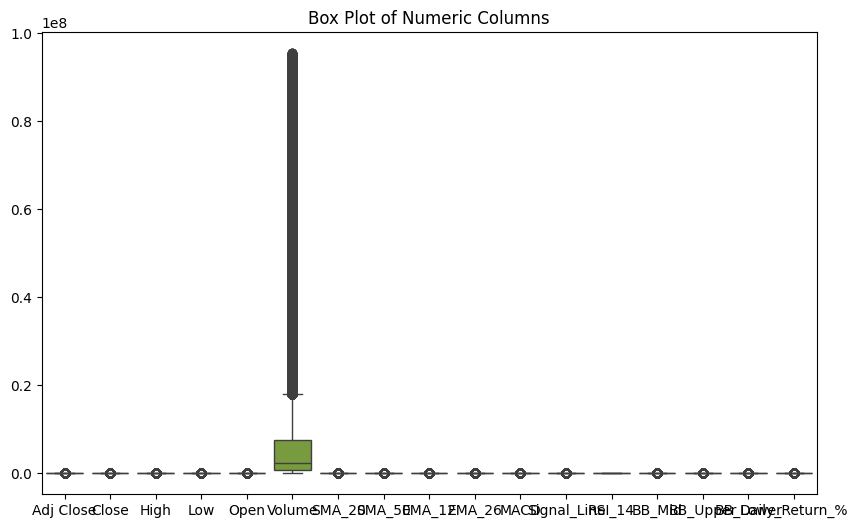

In [ ]:
# find outliers
# Select only numeric columns for quantile calculation to avoid TypeError on string columns
numeric_cols = new_df.select_dtypes(include=np.number).columns
new_df = new_df[(new_df[numeric_cols] >= new_df[numeric_cols].quantile(0.01)) & (new_df[numeric_cols] <= new_df[numeric_cols].quantile(0.99))]
plt.figure(figsize=(10, 6))
sns.boxplot(data=new_df[numeric_cols])
plt.title('Box Plot of Numeric Columns')
plt.show()


In [ ]:
# find percentage of outliesrs in datasets
numeric_cols = new_df.select_dtypes(include=np.number).columns
outlier_counts = (new_df[numeric_cols]).value_counts()
outlier_percentages = (outlier_counts / len(new_df)) * 100
numeric_cols = new_df.select_dtypes(include=np.number).columns
outlier_percentages = (new_df[numeric_cols]).value_counts()
print(outlier_percentages)

Adj Close     Close         High         Low          Open          Volume      SMA_20       SMA_50        EMA_12        EMA_26        MACD        Signal_Line  RSI_14     BB_Mid       BB_Upper      BB_Lower      Daily_Return_%
11131.590820  11202.150390  11233.00000  10915.00000  10915.000000  367574.0    11039.01499  11261.046950  11083.803170  11096.254480  -12.451309  -52.628914   53.884467  11039.01499  11463.590110  10614.439870   1.858104         1
1.807262      2.810000      2.81000      2.81000      2.810000      0.0         2.98925      3.300200      2.871239      3.031175      -0.159936   -0.159591    14.960629  2.98925      3.412586      2.565914       0.000000         1
                            2.99000      2.77500      2.965000      46550.0     3.00900      3.317200      2.882373      3.048869      -0.166495   -0.159505    38.636365  3.00900      3.433978      2.584022       1.444042         1
1.808070      2.960000      3.16000      2.90000      3.160000      319000.0 

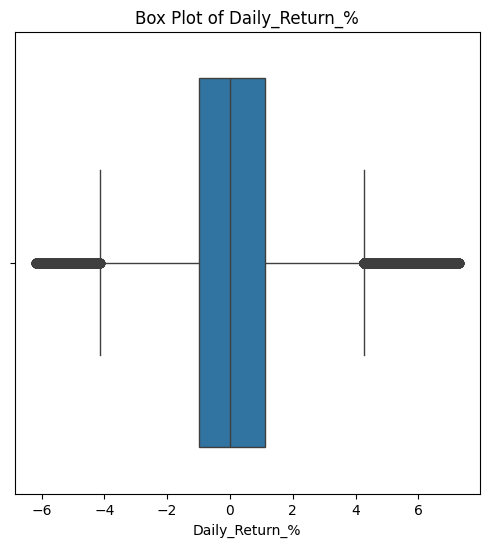

In [ ]:
# Treatment of outliers drop outliers from the data set
plt.figure(figsize=(6, 6))
# Resetting index locally for the plot to avoid duplicate label errors
sns.boxplot(data=new_df.reset_index(), x='Daily_Return_%')
plt.title('Box Plot of Daily_Return_%')
plt.show()

In [ ]:
"""
=============================================================
  NIFTY 50 DATA ANALYTICS PROJECT
  Step 1: Data Collection using yfinance
=============================================================
"""

import yfinance as yf
import pandas as pd
import numpy as np
import os
from datetime import datetime

# ─── CONFIG ───────────────────────────────────────────────
START_DATE  = "2020-01-01"
END_DATE    = datetime.today().strftime("%Y-%m-%d")
OUTPUT_DIR  = "data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── ALL 50 NIFTY STOCKS ─────────────────────────────────
NIFTY50_STOCKS = {
    "RELIANCE.NS": "Reliance Industries", "TCS.NS": "Tata Consultancy Services",
    "HDFCBANK.NS": "HDFC Bank", "INFY.NS": "Infosys", "ICICIBANK.NS": "ICICI Bank",
    "HINDUNILVR.NS": "Hindustan Unilever", "ITC.NS": "ITC Limited", "SBIN.NS": "State Bank of India",
    "BHARTIARTL.NS": "Bharti Airtel", "KOTAKBANK.NS": "Kotak Mahindra Bank", "LT.NS": "Larsen & Toubro",
    "HCLTECH.NS": "HCL Technologies", "ASIANPAINT.NS": "Asian Paints", "AXISBANK.NS": "Axis Bank",
    "MARUTI.NS": "Maruti Suzuki", "SUNPHARMA.NS": "Sun Pharma", "WIPRO.NS": "Wipro",
    "ULTRACEMCO.NS": "UltraTech Cement", "TITAN.NS": "Titan Company", "BAJFINANCE.NS": "Bajaj Finance",
    "NESTLEIND.NS": "Nestle India", "POWERGRID.NS": "Power Grid", "NTPC.NS": "NTPC",
    "TECHM.NS": "Tech Mahindra", "ONGC.NS": "ONGC", "JSWSTEEL.NS": "JSW Steel",
    "TATAMOTORS.NS": "Tata Motors", "ADANIENT.NS": "Adani Enterprises", "BAJAJFINSV.NS": "Bajaj Finserv",
    "COALINDIA.NS": "Coal India", "DIVISLAB.NS": "Divi's Laboratories", "DRREDDY.NS": "Dr. Reddy's Labs",
    "EICHERMOT.NS": "Eicher Motors", "GRASIM.NS": "Grasim Industries", "HDFCLIFE.NS": "HDFC Life",
    "HEROMOTOCO.NS": "Hero MotoCorp", "HINDALCO.NS": "Hindalco", "INDUSINDBK.NS": "IndusInd Bank",
    "IOC.NS": "Indian Oil Corp", "M&M.NS": "Mahindra & Mahindra", "SBILIFE.NS": "SBI Life Insurance",
    "SHREECEM.NS": "Shree Cement", "TATACONSUM.NS": "Tata Consumer", "TATASTEEL.NS": "Tata Steel",
    "CIPLA.NS": "Cipla", "APOLLOHOSP.NS": "Apollo Hospitals", "ADANIPORTS.NS": "Adani Ports",
    "BPCL.NS": "BPCL", "UPL.NS": "UPL", "BRITANNIA.NS": "Britannia"
}

def download_data():
    print(f"\nDownloading Nifty 50 Data...")
    all_data = {}

    for ticker, name in NIFTY50_STOCKS.items():
        try:
            df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
            if not df.empty:
                df["Ticker"] = ticker
                df["Company"] = name
                df["Daily_Return"] = df["Close"].pct_change()
                df["Cumulative_Return"] = (1 + df["Daily_Return"]).cumprod() - 1
                df["MA_20"] = df["Close"].rolling(20).mean()
                df["MA_50"] = df["Close"].rolling(50).mean()
                all_data[ticker] = df
                print(f"  ✔ {name} downloaded.")
        except Exception as e:
            print(f"  ✘ {name} ERROR: {e}")

    if all_data:
        combined = pd.concat(all_data.values(), axis=0)
        # Saving to multiple locations
        combined.to_csv(f"{OUTPUT_DIR}/nifty50_all_stocks.csv")
        combined.to_csv("/content/NIFTY_50_COMPANIES.csv")
        print(f"\n✔ Saved to {OUTPUT_DIR}/nifty50_all_stocks.csv and /content/NIFTY_50_COMPANIES.csv")

        # Create summary
        summary_rows = []
        for ticker, df in all_data.items():
            summary_rows.append({
                "Ticker": ticker,
                "Company": NIFTY50_STOCKS[ticker],
                "Last_Price": round(df["Close"].iloc[-1], 2),
                "Cumulative_Return_%": round(df["Cumulative_Return"].iloc[-1] * 100, 2)
            })
        summary = pd.DataFrame(summary_rows).sort_values("Cumulative_Return_%", ascending=False)
        summary.to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)
        return all_data
    return {}

if __name__ == "__main__":
    stock_data = download_data()


  ✔ Reliance Industries downloaded.
  ✔ Tata Consultancy Services downloaded.
  ✔ HDFC Bank downloaded.
  ✔ Infosys downloaded.
  ✔ ICICI Bank downloaded.
  ✔ Hindustan Unilever downloaded.
  ✔ ITC Limited downloaded.
  ✔ State Bank of India downloaded.
  ✔ Bharti Airtel downloaded.
  ✔ Kotak Mahindra Bank downloaded.
  ✔ Larsen & Toubro downloaded.
  ✔ HCL Technologies downloaded.
  ✔ Asian Paints downloaded.
  ✔ Axis Bank downloaded.
  ✔ Maruti Suzuki downloaded.
  ✔ Sun Pharma downloaded.
  ✔ Wipro downloaded.
  ✔ UltraTech Cement downloaded.
  ✔ Titan Company downloaded.
  ✔ Bajaj Finance downloaded.
  ✔ Nestle India downloaded.
  ✔ Power Grid downloaded.
  ✔ NTPC downloaded.


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


  ✔ Tech Mahindra downloaded.
  ✔ ONGC downloaded.
  ✔ JSW Steel downloaded.
  ✔ Adani Enterprises downloaded.
  ✔ Bajaj Finserv downloaded.
  ✔ Coal India downloaded.
  ✔ Divi's Laboratories downloaded.
  ✔ Dr. Reddy's Labs downloaded.
  ✔ Eicher Motors downloaded.
  ✔ Grasim Industries downloaded.
  ✔ HDFC Life downloaded.
  ✔ Hero MotoCorp downloaded.
  ✔ Hindalco downloaded.
  ✔ IndusInd Bank downloaded.
  ✔ Indian Oil Corp downloaded.
  ✔ Mahindra & Mahindra downloaded.
  ✔ SBI Life Insurance downloaded.
  ✔ Shree Cement downloaded.
  ✔ Tata Consumer downloaded.
  ✔ Tata Steel downloaded.
  ✔ Cipla downloaded.
  ✔ Apollo Hospitals downloaded.
  ✔ Adani Ports downloaded.
  ✔ BPCL downloaded.
  ✔ UPL downloaded.
  ✔ Britannia downloaded.

✔ Saved to data/nifty50_all_stocks.csv and /content/NIFTY_50_COMPANIES.csv


In [ ]:
"""
=============================================================
  NIFTY 50 DATA ANALYTICS PROJECT
  Step 6: Power BI Setup + MASTER RUN SCRIPT
=============================================================
"""

# ============================================================
# POWER BI GUIDE
# ============================================================
POWERBI_GUIDE = """
================= POWER BI SETUP GUIDE =================

Import these files from /data:
- nifty50_all_stocks.csv
- stock_scores.csv
- predictions_summary.csv
- summary.csv

========================================================
"""

print(POWERBI_GUIDE)


# ── MASTER RUN SCRIPT ─────────────────────────────────
import subprocess
import sys
import os


BASE_DIR = os.path.dirname(os.path.abspath(__file__))


def ensure_directories():
    """Ensure required folders exist"""
    required_dirs = ["data", "charts"]
    for d in required_dirs:
        path = os.path.join(BASE_DIR, d)
        if not os.path.exists(path):
            os.makedirs(path)
            print(f"📁 Created missing folder: {d}")


def run_step(script, step_name):
    print(f"\n{'='*60}")
    print(f"Running: {step_name}")
    print(f"{'='*60}")

    script_path = os.path.join(BASE_DIR, script)

    if not os.path.exists(script_path):
        print(f"⚠ {script} not found — skipping")
        return

    try:
        result = subprocess.run(
            [sys.executable, script_path],
            check=True
        )
        print(f"✅ {step_name} completed successfully!")

    except subprocess.CalledProcessError as e:
        print(f"❌ {step_name} failed with error code {e.returncode}")
        print("Stopping pipeline...")
        sys.exit(1)


def run_full_pipeline():
    print("\n" + "="*60)
    print("🚀 NIFTY 50 FULL ANALYTICS PIPELINE — STARTING")
    print("="*60)

    ensure_directories()

    steps = [
        ("01_data_collection.py", "Step 1: Data Collection"),
        ("02_eda.py", "Step 2: Exploratory Data Analysis"),
        ("03_stock_analysis.py", "Step 3: Stock Scoring"),
        ("04_predictions.py", "Step 4: ML Price Predictions"),
        ("05_dashboard.py", "Step 5: Dashboard & Reports"),
    ]

    for script, name in steps:
        run_step(script, name)

    print("\n" + "="*60)
    print("✅ FULL PIPELINE COMPLETE!")
    print("="*60)
    print("Outputs:")
    print("data/nifty50_all_stocks.csv")
    print("data/stock_scores.csv")
    print("data/predictions_summary.csv")
    print("charts/")
    print("="*60)


if __name__ == "__main__":
    run_full_pipeline()

 
================= POWER BI SETUP GUIDE =================

Import these files from /data:
- nifty50_all_stocks.csv
- stock_scores.csv
- predictions_summary.csv
- summary.csv




NameError: name '__file__' is not defined

In [ ]:
"""
=============================================================
  NIFTY 50 DATA ANALYTICS PROJECT
  Step 3: Stock Scoring, Ranking & Best Stocks to Buy
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

OUTPUT_CHARTS = "charts/analysis"
os.makedirs(OUTPUT_CHARTS, exist_ok=True)

# ─── SECTOR MAPPING ──────────────────────────────────────
SECTOR_MAP = {
    "RELIANCE.NS": "Energy",    "ONGC.NS": "Energy",       "IOC.NS": "Energy",
    "BPCL.NS": "Energy",        "COALINDIA.NS": "Energy",
    "TCS.NS": "IT",             "INFY.NS": "IT",            "HCLTECH.NS": "IT",
    "WIPRO.NS": "IT",           "TECHM.NS": "IT",
    "HDFCBANK.NS": "Banking",   "ICICIBANK.NS": "Banking",  "SBIN.NS": "Banking",
    "KOTAKBANK.NS": "Banking",  "AXISBANK.NS": "Banking",   "INDUSINDBK.NS": "Banking",
    "HINDUNILVR.NS": "FMCG",    "ITC.NS": "FMCG",          "NESTLEIND.NS": "FMCG",
    "TATACONSUM.NS": "FMCG",    "BRITANNIA.NS": "FMCG",
    "BHARTIARTL.NS": "Telecom",
    "LT.NS": "Infrastructure",  "ADANIPORTS.NS": "Infrastructure",
    "POWERGRID.NS": "Infrastructure", "NTPC.NS": "Infrastructure",
    "MARUTI.NS": "Auto",        "TATAMOTORS.NS": "Auto",    "HEROMOTOCO.NS": "Auto",
    "EICHERMOT.NS": "Auto",     "M&M.NS": "Auto",
    "SUNPHARMA.NS": "Pharma",   "DIVISLAB.NS": "Pharma",    "DRREDDY.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "BAJFINANCE.NS": "Finance",  "BAJAJFINSV.NS": "Finance",
    "HDFCLIFE.NS": "Finance",    "SBILIFE.NS": "Finance",
    "ASIANPAINT.NS": "Consumer", "TITAN.NS": "Consumer",
    "APOLLOHOSP.NS": "Healthcare",
    "ULTRACEMCO.NS": "Cement",  "SHREECEM.NS": "Cement",    "GRASIM.NS": "Cement",
    "JSWSTEEL.NS": "Metal",     "TATASTEEL.NS": "Metal",    "HINDALCO.NS": "Metal",
    "ADANIENT.NS": "Conglomerate", "UPL.NS": "Chemicals",
}


# ─── COMPUTE COMPREHENSIVE SCORES ────────────────────────
def compute_scores(df):
    """
    Score each stock across 7 dimensions:
      1. Momentum Score    — 1Y vs 6M vs 3M returns trend
      2. Volatility Score  — lower volatility = better
      3. RSI Score         — near 50 (neutral) is healthiest
      4. Sharpe Ratio      — risk-adjusted return
      5. Trend Score       — price vs MA50/MA200
      6. Volume Score      — increasing volume trend
      7. Consistency Score — win rate (% positive days)
    """
    records = []

    for ticker, sub in df.groupby("Ticker"):
        sub = sub.sort_index()
        try:
            close = sub["Close"].dropna()
            ret   = sub["Daily_Return"].dropna()

            if len(close) < 60:
                continue

            # ── Momentum ──────────────────────────────────
            ret_1y = (close.iloc[-1] / close.iloc[-252] - 1) if len(close) >= 252 else np.nan
            ret_6m = (close.iloc[-1] / close.iloc[-126] - 1) if len(close) >= 126 else np.nan
            ret_3m = (close.iloc[-1] / close.iloc[-63]  - 1) if len(close) >= 63  else np.nan

            # Positive momentum: 3M > 6M/2 shows acceleration
            momentum = np.nanmean([ret_1y, ret_6m, ret_3m])

            # ── Sharpe Ratio (annualized) ──────────────────
            rf_daily = 0.065 / 252   # 6.5% risk-free rate
            excess   = ret - rf_daily
            sharpe   = (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() > 0 else 0

            # ── Volatility (lower = better) ───────────────
            vol_20 = ret.rolling(20).std().iloc[-1] * np.sqrt(252)

            # ── RSI (last value) ─────────────────────────
            rsi_last = sub["RSI"].dropna().iloc[-1] if "RSI" in sub.columns else 50

            # ── Trend (price vs MAs) ──────────────────────
            last_close = close.iloc[-1]
            ma50  = sub["MA_50"].dropna().iloc[-1]  if "MA_50"  in sub.columns else last_close
            ma200 = sub["MA_200"].dropna().iloc[-1] if "MA_200" in sub.columns else last_close
            trend_score = (
                (1 if last_close > ma50  else -1) +
                (1 if last_close > ma200 else -1) +
                (1 if ma50 > ma200 else -1)        # Golden cross
            )

            # ── Volume Trend ─────────────────────────────
            vol_last30  = sub["Volume"].iloc[-30:].mean()
            vol_prev30  = sub["Volume"].iloc[-60:-30].mean()
            vol_trend   = (vol_last30 / vol_prev30 - 1) if vol_prev30 > 0 else 0

            # ── Consistency ──────────────────────────────
            win_rate = (ret > 0).mean()

            # ── Max Drawdown ──────────────────────────────
            rolling_max = close.cummax()
            drawdown    = (close - rolling_max) / rolling_max
            max_dd      = drawdown.min()

            records.append({
                "Ticker":      ticker,
                "Company":     sub["Company"].iloc[0],
                "Sector":      SECTOR_MAP.get(ticker, "Other"),
                "Last_Price":  round(last_close, 2),
                "Ret_1Y_%":    round(ret_1y   * 100, 2) if ret_1y   is not None else np.nan,
                "Ret_6M_%":    round(ret_6m   * 100, 2) if ret_6m   is not None else np.nan,
                "Ret_3M_%":    round(ret_3m   * 100, 2) if ret_3m   is not None else np.nan,
                "Momentum":    momentum,
                "Sharpe":      sharpe,
                "Volatility":  vol_20,
                "RSI_Last":    rsi_last,
                "Trend_Score": trend_score,
                "Vol_Trend":   vol_trend,
                "Win_Rate":    win_rate,
                "Max_Drawdown_%": round(max_dd * 100, 2),
            })

        except Exception as e:
            print(f"  ⚠ Skipping {ticker}: {e}")

    scores_df = pd.DataFrame(records)

    # ── Normalize scores 0–100 ────────────────────────────
    def rank_norm(series, ascending=True):
        """Rank-normalize to 0–100."""
        ranked = series.rank(ascending=ascending, pct=True) * 100
        return ranked.fillna(50)

    scores_df["S_Momentum"]    = rank_norm(scores_df["Momentum"],    ascending=True)
    scores_df["S_Sharpe"]      = rank_norm(scores_df["Sharpe"],      ascending=True)
    scores_df["S_Volatility"]  = rank_norm(scores_df["Volatility"],  ascending=False)  # lower is better
    scores_df["S_RSI"]         = 100 - abs(scores_df["RSI_Last"] - 50) * 2  # closer to 50 = better
    scores_df["S_Trend"]       = rank_norm(scores_df["Trend_Score"], ascending=True)
    scores_df["S_Volume"]      = rank_norm(scores_df["Vol_Trend"],   ascending=True)
    scores_df["S_WinRate"]     = rank_norm(scores_df["Win_Rate"],    ascending=True)

    # ── Weighted Composite Score ──────────────────────────
    weights = {
        "S_Momentum":   0.25,
        "S_Sharpe":     0.25,
        "S_Volatility": 0.15,
        "S_RSI":        0.10,
        "S_Trend":      0.10,
        "S_Volume":     0.08,
        "S_WinRate":    0.07,
    }

    scores_df["Composite_Score"] = sum(
        scores_df[col] * w for col, w in weights.items()
    )
    scores_df["Composite_Score"] = scores_df["Composite_Score"].round(2)
    scores_df = scores_df.sort_values("Composite_Score", ascending=False).reset_index(drop=True)
    scores_df["Rank"] = scores_df.index + 1

    # ── Buy Rating ────────────────────────────────────────
    def rating(score):
        if score >= 75: return "🟢 STRONG BUY"
        if score >= 60: return "🔵 BUY"
        if score >= 45: return "🟡 HOLD"
        if score >= 30: return "🟠 UNDERPERFORM"
        return "🔴 AVOID"

    scores_df["Rating"] = scores_df["Composite_Score"].apply(rating)

    scores_df.to_csv("data/stock_scores.csv", index=False)
    print("  ✔ Saved → data/stock_scores.csv")
    return scores_df


# ─── PRINT TOP RECOMMENDATIONS ───────────────────────────
def print_recommendations(scores_df):
    print("\n" + "="*75)
    print("  🏆 TOP 10 NIFTY 50 STOCKS — RANKED BY COMPOSITE SCORE")
    print("="*75)
    top10 = scores_df.head(10)
    cols  = ["Rank","Company","Sector","Last_Price","Ret_1Y_%",
             "Sharpe","Composite_Score","Rating"]
    print(top10[cols].to_string(index=False))

    print("\n" + "="*75)
    print("  💡 DETAILED ANALYSIS — TOP 5 BUY RECOMMENDATIONS")
    print("="*75)
    for _, row in scores_df.head(5).iterrows():
        reasons = []
        if row["Ret_1Y_%"] > 20:    reasons.append(f"Strong 1Y return (+{row['Ret_1Y_%']:.1f}%)")
        if row["Sharpe"] > 1.0:     reasons.append(f"Excellent Sharpe ratio ({row['Sharpe']:.2f})")
        if row["Volatility"] < 0.3: reasons.append(f"Low volatility ({row['Volatility']*100:.1f}%)")
        if row["RSI_Last"] < 65:    reasons.append(f"RSI not overbought ({row['RSI_Last']:.1f})")
        if row["Trend_Score"] >= 2: reasons.append("Above MA50 & MA200 (bullish trend)")
        if row["Win_Rate"] > 0.53:  reasons.append(f"High win rate ({row['Win_Rate']*100:.1f}%)")
        if row["Max_Drawdown_%"] > -30: reasons.append(f"Manageable drawdown ({row['Max_Drawdown_%']:.1f}%)")

        print(f"\n  #{int(row['Rank'])} {row['Company']} ({row['Ticker']})")
        print(f"     Rating      : {row['Rating']}")
        print(f"     Sector      : {row['Sector']}")
        print(f"     Price       : ₹{row['Last_Price']:,.2f}")
        print(f"     Composite   : {row['Composite_Score']:.1f}/100")
        print(f"     Why to Buy  :")
        for r in reasons:
            print(f"       ✔ {r}")
        if not reasons:
            print("       ✔ Top-ranked by multi-factor composite model")


# ─── VISUALIZATION ────────────────────────────────────────
def plot_scores(scores_df):
    top15 = scores_df.head(15)

    # ── 1. Radar Chart for Top 5 ──────────────────────────
    categories = ["Momentum","Sharpe","Low Volatility","RSI","Trend","Volume","Win Rate"]
    cols       = ["S_Momentum","S_Sharpe","S_Volatility","S_RSI","S_Trend","S_Volume","S_WinRate"]
    N          = len(categories)
    angles     = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

    fig, axes = plt.subplots(1, 5, figsize=(24, 6), subplot_kw=dict(polar=True))
    fig.suptitle("🕸️ Multi-Factor Radar Chart — Top 5 Buy Recommendations", fontsize=14, fontweight="bold")
    colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]

    for i, (_, row) in enumerate(scores_df.head(5).iterrows()):
        ax     = axes[i]
        values = [row[c] for c in cols] + [row[cols[0]]]
        ax.plot(angles, values, color=colors[i], linewidth=2)
        ax.fill(angles, values, color=colors[i], alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=8)
        ax.set_ylim(0, 100)
        ax.set_title(f"#{i+1} {row['Ticker'].replace('.NS','')}\n{row['Rating']}",
                     fontsize=9, fontweight="bold", pad=15)
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_CHARTS}/12_radar_top5.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  ✔ Saved: 12_radar_top5.png")

    # ── 2. Score Bar Chart ────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 10))
    color_map = {
        "🟢 STRONG BUY": "#2ca02c", "🔵 BUY": "#1f77b4",
        "🟡 HOLD": "#bcbd22", "🟠 UNDERPERFORM": "#ff7f0e", "🔴 AVOID": "#d62728"
    }
    colors = [color_map.get(r, "gray") for r in top15["Rating"]]
    bars   = ax.barh(range(len(top15)), top15["Composite_Score"],
                     color=colors, edgecolor="white", height=0.7)

    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels([f"{r['Company'][:22]}" for _, r in top15.iterrows()], fontsize=9)
    ax.set_xlabel("Composite Score (0–100)", fontsize=11)
    ax.set_title("🏆 Top 15 Nifty 50 Stocks — Composite Score Ranking", fontsize=13, fontweight="bold")
    ax.axvline(75, color="green", linestyle="--", alpha=0.5, label="Strong Buy Threshold")
    ax.axvline(60, color="blue",  linestyle="--", alpha=0.5, label="Buy Threshold")

    for bar, (_, row) in zip(bars, top15.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f" {row['Composite_Score']:.1f}  {row['Rating']}",
                va="center", fontsize=8)
    ax.invert_yaxis()
    ax.legend(loc="lower right")

    legend_patches = [mpatches.Patch(color=v, label=k) for k,v in color_map.items()]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
    ax.set_xlim(0, 110)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_CHARTS}/13_composite_score_ranking.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  ✔ Saved: 13_composite_score_ranking.png")

    # ── 3. Score Components Heatmap ───────────────────────
    score_cols = ["S_Momentum","S_Sharpe","S_Volatility","S_RSI","S_Trend","S_Volume","S_WinRate"]
    heat_data  = top15.set_index("Company")[score_cols].rename(columns={
        "S_Momentum":"Momentum","S_Sharpe":"Sharpe","S_Volatility":"Low Vol",
        "S_RSI":"RSI","S_Trend":"Trend","S_Volume":"Volume","S_WinRate":"Win Rate"
    })

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="RdYlGn",
                vmin=0, vmax=100, ax=ax, linewidths=0.5,
                cbar_kws={"label": "Score (0–100)"})
    ax.set_title("📊 Score Breakdown — Top 15 Stocks (per factor)", fontsize=13, fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_CHARTS}/14_score_heatmap.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  ✔ Saved: 14_score_heatmap.png")

    # ── 4. Sharpe vs Return ────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(scores_df["Sharpe"], scores_df["Ret_1Y_%"],
                         c=scores_df["Composite_Score"], cmap="RdYlGn",
                         s=120, edgecolors="white", linewidths=0.5, vmin=30, vmax=80)
    plt.colorbar(scatter, ax=ax, label="Composite Score")

    for _, row in scores_df.head(10).iterrows():
        ax.annotate(row["Ticker"].replace(".NS",""),
                    (row["Sharpe"], row["Ret_1Y_%"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8, fontweight="bold")

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(1, color="blue", linestyle="--", alpha=0.5, label="Sharpe > 1 (Good)")
    ax.set_xlabel("Sharpe Ratio (Risk-Adjusted Return)", fontsize=11)
    ax.set_ylabel("1-Year Return (%)", fontsize=11)
    ax.set_title("📈 Sharpe Ratio vs 1-Year Return — All Nifty 50 Stocks", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_CHARTS}/15_sharpe_vs_return.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  ✔ Saved: 15_sharpe_vs_return.png")


# ─── MAIN ────────────────────────────────────────────────
def run_analysis():
    print("\n" + "="*60)
    print("  NIFTY 50 Stock Scoring & Recommendations")
    print("="*60)

    df      = pd.read_csv("data/nifty50_all_stocks.csv", index_col=0, parse_dates=True)
    summary = pd.read_csv("data/summary.csv")

    scores_df = compute_scores(df)
    print_recommendations(scores_df)
    print("\n  Generating Visualization Charts...")
    plot_scores(scores_df)

    print(f"\n  ✅ Analysis complete! Charts saved to: {OUTPUT_CHARTS}/")
    return scores_df


if __name__ == "__main__":
    run_analysis()


In [ ]:
"""
=============================================================
  NIFTY 50 DATA ANALYTICS PROJECT
  Step 4: Future Price Prediction (ML + Time Series)
  Models: Linear Regression, Random Forest, LSTM-like ARIMA
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os
from datetime import timedelta

from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics       import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

OUTPUT_CHARTS = "charts/predictions"
os.makedirs(OUTPUT_CHARTS, exist_ok=True)


# ─── FEATURE ENGINEERING ─────────────────────────────────
def create_features(df_stock):
    """Create lag features + technical indicators for ML models."""
    df = df_stock.copy().sort_index()
    close = df["Close"]

    # Lag features
    for lag in [1, 2, 3, 5, 10, 20]:
        df[f"Lag_{lag}"] = close.shift(lag)

    # Rolling stats
    for window in [5, 10, 20, 50]:
        df[f"Rolling_Mean_{window}"] = close.rolling(window).mean()
        df[f"Rolling_Std_{window}"]  = close.rolling(window).std()

    # Technical indicators
    df["RSI"]     = df["RSI"]     if "RSI"     in df else np.nan
    df["MACD"]    = df["MACD"]    if "MACD"    in df else np.nan
    df["MA_20"]   = df["MA_20"]   if "MA_20"   in df else np.nan
    df["MA_50"]   = df["MA_50"]   if "MA_50"   in df else np.nan

    # Price change ratios
    df["Price_Change_1D"] = close.pct_change(1)
    df["Price_Change_5D"] = close.pct_change(5)
    df["Price_Change_20D"]= close.pct_change(20)

    # Day of week / month seasonality
    df["DayOfWeek"] = df.index.dayofweek
    df["Month"]     = df.index.month

    # Target: next day close
    df["Target"] = close.shift(-1)

    df.dropna(inplace=True)
    return df


# ─── TRAIN MODELS ────────────────────────────────────────
def train_predict(df_stock, ticker, forecast_days=90):
    """Train 3 ML models and predict future prices."""
    print(f"\n  📊 Training models for {ticker}...")

    engineered = create_features(df_stock)
    if len(engineered) < 100:
        print(f"  ⚠ Not enough data for {ticker}")
        return None

    feature_cols = [c for c in engineered.columns
                    if c not in ["Target","Ticker","Company","Open","High","Low",
                                 "Volume","Close","Adj Close"]]
    feature_cols = [c for c in feature_cols if engineered[c].dtype in [float, int, np.float64]]

    X = engineered[feature_cols].values
    y = engineered["Target"].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # ── Model 1: Linear Regression ──
    lr = LinearRegression()
    lr.fit(X_train_s, y_train)
    y_pred_lr = lr.predict(X_test_s)

    # ── Model 2: Random Forest ──────
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train_s, y_train)
    y_pred_rf = rf.predict(X_test_s)

    # ── Model 3: Gradient Boosting ──
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
    gb.fit(X_train_s, y_train)
    y_pred_gb = gb.predict(X_test_s)

    # ── Metrics ──────────────────────
    results = {}
    for name, preds in [("Linear Regression", y_pred_lr),
                         ("Random Forest",     y_pred_rf),
                         ("Gradient Boosting", y_pred_gb)]:
        mae   = mean_absolute_error(y_test, preds)
        rmse  = np.sqrt(mean_squared_error(y_test, preds))
        r2    = r2_score(y_test, preds)
        mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100
        results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape, "preds": preds}
        print(f"    {name:<22} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")

    # Best model
    best_name = min(results, key=lambda k: results[k]["MAPE"])
    print(f"    ⭐ Best Model: {best_name}")

    # ── Future Forecast (iterative) ──
    last_features = engineered[feature_cols].iloc[-1].values.reshape(1, -1)
    last_price    = df_stock["Close"].iloc[-1]
    last_date     = df_stock.index[-1]

    future_dates  = pd.bdate_range(start=last_date + timedelta(days=1), periods=forecast_days)
    future_prices_rf = []
    future_prices_gb = []

    # Simple rolling forecast using last known features
    feat_rf = scaler.transform(last_features)
    feat_gb = scaler.transform(last_features)

    for d in range(forecast_days):
        p_rf = rf.predict(feat_rf)[0]
        p_gb = gb.predict(feat_gb)[0]
        future_prices_rf.append(p_rf)
        future_prices_gb.append(p_gb)

        # Update lag feature (simplified: shift lag_1 based on prediction)
        new_feat_rf = feat_rf.copy()
        new_feat_gb = feat_gb.copy()
        # Update Lag_1 (index 0 in feature_cols)
        if "Lag_1" in feature_cols:
            idx = feature_cols.index("Lag_1")
            new_feat_rf[0, idx] = p_rf
            new_feat_gb[0, idx] = p_gb
        feat_rf = new_feat_rf
        feat_gb = new_feat_gb

    # Ensemble (average)
    future_ensemble = [(a + b) / 2 for a, b in zip(future_prices_rf, future_prices_gb)]

    # Confidence bands (± 1.5 * RMSE of best model)
    rmse_best = results[best_name]["RMSE"]
    upper = [p + 1.5 * rmse_best for p in future_ensemble]
    lower = [p - 1.5 * rmse_best for p in future_ensemble]

    return {
        "ticker":         ticker,
        "company":        df_stock["Company"].iloc[0],
        "last_price":     last_price,
        "test_dates":     engineered.index[-len(y_test):],
        "y_test":         y_test,
        "y_pred_lr":      y_pred_lr,
        "y_pred_rf":      y_pred_rf,
        "y_pred_gb":      y_pred_gb,
        "future_dates":   future_dates,
        "future_rf":      future_prices_rf,
        "future_gb":      future_prices_gb,
        "future_ensemble":future_ensemble,
        "upper":          upper,
        "lower":          lower,
        "results":        results,
        "best_model":     best_name,
        "history":        df_stock["Close"],
    }


# ─── PLOT PREDICTIONS ────────────────────────────────────
def plot_prediction(result):
    if result is None:
        return

    ticker   = result["ticker"]
    company  = result["company"]
    last_price = result["last_price"]
    target_price = result["future_ensemble"][-1]
    pct_change   = (target_price - last_price) / last_price * 100
    direction    = "📈 UP" if pct_change > 0 else "📉 DOWN"

    fig = plt.figure(figsize=(18, 12))
    gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

    # ── Top full width: Full history + forecast ───────────
    ax1 = fig.add_subplot(gs[0, :])
    hist = result["history"].iloc[-252:]   # last 1 year
    ax1.plot(hist.index, hist.values, color="#1f77b4", linewidth=1.8, label="Historical Price")
    ax1.plot(result["future_dates"], result["future_ensemble"],
             color="#d62728", linewidth=2.5, linestyle="--", label="Ensemble Forecast")
    ax1.fill_between(result["future_dates"], result["lower"], result["upper"],
                     alpha=0.2, color="#d62728", label="Confidence Band (±1.5σ)")
    ax1.axvline(hist.index[-1], color="gray", linestyle=":", linewidth=1.5, label="Forecast Start")
    ax1.set_title(f"🔮 {company} — 90-Day Price Forecast\n"
                  f"Current: ₹{last_price:,.2f}  |  90D Target: ₹{target_price:,.2f}  |  Expected: {direction} {abs(pct_change):.1f}%",
                  fontsize=12, fontweight="bold")
    ax1.set_ylabel("Price (₹)")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax1.tick_params(axis="x", rotation=30)

    # ── Bottom left: Model comparison ────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(result["test_dates"], result["y_test"],    color="black", linewidth=1.5, label="Actual")
    ax2.plot(result["test_dates"], result["y_pred_lr"], color="blue",  linewidth=1.2, linestyle="--", label="Linear Reg", alpha=0.8)
    ax2.plot(result["test_dates"], result["y_pred_rf"], color="green", linewidth=1.2, linestyle="--", label="Random Forest", alpha=0.8)
    ax2.plot(result["test_dates"], result["y_pred_gb"], color="red",   linewidth=1.2, linestyle="--", label="Grad. Boost", alpha=0.8)
    ax2.set_title("Model Comparison — Test Set Predictions", fontsize=10, fontweight="bold")
    ax2.set_ylabel("Price (₹)")
    ax2.legend(fontsize=8)
    ax2.tick_params(axis="x", rotation=30)

    # ── Bottom right: Model metrics ──────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis("off")
    metrics_data = []
    for name, m in result["results"].items():
        metrics_data.append([
            name, f"{m['MAE']:.2f}", f"{m['RMSE']:.2f}",
            f"{m['R2']:.4f}", f"{m['MAPE']:.2f}%",
            "⭐" if name == result["best_model"] else ""
        ])

    table = ax3.table(
        cellText=metrics_data,
        colLabels=["Model","MAE","RMSE","R²","MAPE","Best"],
        loc="center", cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor("#2E75B6")
            cell.set_text_props(color="white", fontweight="bold")
        elif metrics_data[r-1][-1] == "⭐":
            cell.set_facecolor("#E8F5E9")
        else:
            cell.set_facecolor("#F5F5F5" if r % 2 else "white")
    ax3.set_title(f"📋 Model Performance Metrics\n{company}", fontsize=10, fontweight="bold", pad=20)

    plt.suptitle(f"Nifty 50 — ML Price Prediction Dashboard | {company} ({ticker})",
                 fontsize=13, fontweight="bold", y=1.01)
    safe  = ticker.replace(".", "_").replace("&", "AND")
    fname = f"{OUTPUT_CHARTS}/predict_{safe}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.close()
    print(f"  ✔ Saved: predict_{safe}.png")
    return fname


# ─── PREDICTION SUMMARY ──────────────────────────────────
def plot_forecast_summary(all_results):
    """Bar chart of expected 90-day returns from all predicted stocks."""
    summary_rows = []
    for r in all_results:
        if r:
            chg = (r["future_ensemble"][-1] - r["last_price"]) / r["last_price"] * 100
            summary_rows.append({
                "Company": r["company"][:22],
                "Ticker":  r["ticker"],
                "Current": r["last_price"],
                "Target":  round(r["future_ensemble"][-1], 2),
                "Expected_%": round(chg, 2),
                "Best_Model": r["best_model"],
            })

    if not summary_rows:
        return

    pred_df = pd.DataFrame(summary_rows).sort_values("Expected_%", ascending=False)
    pred_df.to_csv("data/predictions_summary.csv", index=False)

    fig, ax = plt.subplots(figsize=(14, 9))
    colors  = ["#2ca02c" if x > 0 else "#d62728" for x in pred_df["Expected_%"]]
    bars    = ax.barh(pred_df["Company"], pred_df["Expected_%"], color=colors, edgecolor="white")

    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Expected 90-Day Return (%)", fontsize=11)
    ax.set_title("🔮 90-Day Price Forecast — Expected Returns (ML Ensemble Model)",
                 fontsize=13, fontweight="bold")

    for bar, val in zip(bars, pred_df["Expected_%"]):
        ax.text(bar.get_width() + (0.3 if val >= 0 else -0.3),
                bar.get_y() + bar.get_height() / 2,
                f"  {val:+.1f}%", va="center", fontsize=8,
                ha="left" if val >= 0 else "right")

    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_CHARTS}/16_forecast_summary.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  ✔ Saved: 16_forecast_summary.png")
    print("\n  📊 Prediction Summary:")
    print(pred_df.to_string(index=False))


# ─── MAIN ────────────────────────────────────────────────
def run_predictions(tickers_to_predict=None):
    print("\n" + "="*60)
    print("  NIFTY 50 ML Price Predictions")
    print("="*60)

    df        = pd.read_csv("data/nifty50_all_stocks.csv", index_col=0, parse_dates=True)
    scores_df = pd.read_csv("data/stock_scores.csv") if os.path.exists("data/stock_scores.csv") else None

    # Predict top 10 buy candidates (or all if specified)
    if tickers_to_predict is None:
        if scores_df is not None:
            tickers_to_predict = scores_df.head(10)["Ticker"].tolist()
        else:
            tickers_to_predict = df["Ticker"].unique()[:10]

    all_results = []
    for ticker in tickers_to_predict:
        sub = df[df["Ticker"] == ticker].copy()
        result = train_predict(sub, ticker, forecast_days=90)
        if result:
            plot_prediction(result)
            all_results.append(result)

    print("\n  Generating Forecast Summary...")
    plot_forecast_summary(all_results)

    print(f"\n  ✅ Predictions saved to: {OUTPUT_CHARTS}/")
    return all_results


if __name__ == "__main__":
    results = run_predictions()


In [ ]:
""
=============================================================
  NIFTY 50 DATA ANALYTICS PROJECT
  Step 5: Interactive Dashboard (Plotly HTML Export)
=============================================================
  This creates a fully interactive HTML dashboard you can
  open in any browser — perfect for portfolio presentation!
=============================================================
"""

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import os, warnings

warnings.filterwarnings("ignore")
OUTPUT_DIR = "charts/dashboard"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SECTOR_MAP = {
    "RELIANCE.NS": "Energy",    "ONGC.NS": "Energy",       "IOC.NS": "Energy",
    "BPCL.NS": "Energy",        "COALINDIA.NS": "Energy",
    "TCS.NS": "IT",             "INFY.NS": "IT",            "HCLTECH.NS": "IT",
    "WIPRO.NS": "IT",           "TECHM.NS": "IT",
    "HDFCBANK.NS": "Banking",   "ICICIBANK.NS": "Banking",  "SBIN.NS": "Banking",
    "KOTAKBANK.NS": "Banking",  "AXISBANK.NS": "Banking",   "INDUSINDBK.NS": "Banking",
    "HINDUNILVR.NS": "FMCG",    "ITC.NS": "FMCG",          "NESTLEIND.NS": "FMCG",
    "TATACONSUM.NS": "FMCG",    "BRITANNIA.NS": "FMCG",
    "BHARTIARTL.NS": "Telecom",
    "LT.NS": "Infrastructure",  "ADANIPORTS.NS": "Infrastructure",
    "POWERGRID.NS": "Infrastructure", "NTPC.NS": "Infrastructure",
    "MARUTI.NS": "Auto",        "TATAMOTORS.NS": "Auto",    "HEROMOTOCO.NS": "Auto",
    "EICHERMOT.NS": "Auto",     "M&M.NS": "Auto",
    "SUNPHARMA.NS": "Pharma",   "DIVISLAB.NS": "Pharma",    "DRREDDY.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "BAJFINANCE.NS": "Finance",  "BAJAJFINSV.NS": "Finance",
    "HDFCLIFE.NS": "Finance",    "SBILIFE.NS": "Finance",
    "ASIANPAINT.NS": "Consumer", "TITAN.NS": "Consumer",
    "APOLLOHOSP.NS": "Healthcare",
    "ULTRACEMCO.NS": "Cement",   "SHREECEM.NS": "Cement",   "GRASIM.NS": "Cement",
    "JSWSTEEL.NS": "Metal",      "TATASTEEL.NS": "Metal",   "HINDALCO.NS": "Metal",
    "ADANIENT.NS": "Conglomerate", "UPL.NS": "Chemicals",
}

PLOTLY_COLORS = px.colors.qualitative.Set3


# ─── CHART 1: Interactive Candlestick ────────────────────
def chart_candlestick(df, ticker):
    sub = df[df["Ticker"] == ticker].iloc[-180:].copy()
    company = sub["Company"].iloc[0]

    fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                        row_heights=[0.6, 0.2, 0.2],
                        subplot_titles=["Candlestick + Bollinger Bands", "Volume", "RSI (14)"])

    fig.add_trace(go.Candlestick(
        x=sub.index, open=sub["Open"], high=sub["High"],
        low=sub["Low"], close=sub["Close"], name="OHLC",
        increasing_line_color="#26a69a", decreasing_line_color="#ef5350"
    ), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub.index, y=sub["MA_20"],  name="MA20",  line=dict(color="blue",   width=1.5, dash="dot")), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub.index, y=sub["MA_50"],  name="MA50",  line=dict(color="orange", width=1.5, dash="dot")), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub.index, y=sub["Upper_BB"], name="Upper BB", line=dict(color="gray", width=1), showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub.index, y=sub["Lower_BB"], name="Lower BB", fill="tonexty",
                              fillcolor="rgba(128,128,128,0.1)", line=dict(color="gray", width=1), showlegend=False), row=1, col=1)
    fig.add_trace(go.Bar(x=sub.index, y=sub["Volume"], name="Volume",
                          marker_color=["#26a69a" if c >= o else "#ef5350"
                                        for c, o in zip(sub["Close"], sub["Open"])]), row=2, col=1)
    fig.add_trace(go.Scatter(x=sub.index, y=sub["RSI"], name="RSI", line=dict(color="purple", width=1.5)), row=3, col=1)
    fig.add_hline(y=70, line_dash="dash", line_color="red",   annotation_text="Overbought (70)", row=3, col=1)
    fig.add_hline(y=30, line_dash="dash", line_color="green", annotation_text="Oversold (30)",   row=3, col=1)

    fig.update_layout(
        title=dict(text=f"📈 {company} — Technical Analysis Dashboard (Last 180 Days)", font=dict(size=16)),
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=750,
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=1.02)
    )
    fname = f"{OUTPUT_DIR}/candlestick_{ticker.replace('.','_').replace('&','AND')}.html"
    fig.write_html(fname)
    return fname


# ─── CHART 2: Portfolio Performance Dashboard ─────────────
def chart_portfolio_dashboard(df, scores_df):
    top10 = scores_df.head(10)
    pivot = df[df["Ticker"].isin(top10["Ticker"])].pivot_table(
        index=df.index, columns="Ticker", values="Cumulative_Return"
    ) * 100
    pivot.columns = [c.replace(".NS","") for c in pivot.columns]

    # Returns line chart
    fig1 = go.Figure()
    colors = px.colors.qualitative.Plotly
    for i, col in enumerate(pivot.columns):
        fig1.add_trace(go.Scatter(
            x=pivot.index, y=pivot[col], name=col,
            line=dict(width=2, color=colors[i % len(colors)]),
            hovertemplate=f"<b>{col}</b><br>Return: %{{y:.1f}}%<extra></extra>"
        ))
    fig1.update_layout(
        title="📈 Cumulative Returns (%) — Top 10 Buy Recommendations",
        xaxis_title="Date", yaxis_title="Cumulative Return (%)",
        template="plotly_white", height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02),
        hovermode="x unified"
    )
    fig1.write_html(f"{OUTPUT_DIR}/cumulative_returns.html")

    # Risk-Return Bubble Chart
    top10_data = scores_df.copy()
    top10_data["Sector"] = top10_data["Ticker"].map(SECTOR_MAP).fillna("Other")
    top10_data["Short"]  = top10_data["Ticker"].str.replace(".NS","")

    fig2 = px.scatter(
        top10_data, x="Volatility", y="Ret_1Y_%",
        size="Composite_Score", color="Sector",
        hover_name="Company", text="Short",
        title="⚡ Risk vs Return — Nifty 50 (Bubble size = Composite Score)",
        labels={"Volatility": "Volatility (Annualized)", "Ret_1Y_%": "1-Year Return (%)"},
        template="plotly_white", height=600,
        color_discrete_sequence=PLOTLY_COLORS
    )
    fig2.update_traces(textposition="top center", textfont=dict(size=9))
    fig2.write_html(f"{OUTPUT_DIR}/risk_return_bubble.html")

    # Score Bar Chart
    top15 = scores_df.head(15)
    color_scale = top15["Composite_Score"].tolist()
    fig3 = go.Figure(go.Bar(
        x=top15["Composite_Score"], y=top15["Company"],
        orientation="h",
        marker=dict(color=color_scale, colorscale="RdYlGn",
                    colorbar=dict(title="Score"), showscale=True),
        text=[f"{s:.1f}  {r}" for s, r in zip(top15["Composite_Score"], top15["Rating"])],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Score: %{x:.1f}<extra></extra>"
    ))
    fig3.update_layout(
        title="🏆 Top 15 Stocks — Composite Score Ranking",
        xaxis_title="Composite Score (0–100)", yaxis_autorange="reversed",
        template="plotly_white", height=600,
        xaxis=dict(range=[0, 110])
    )
    fig3.write_html(f"{OUTPUT_DIR}/composite_scores.html")

    # Sector Pie Chart
    sector_data = top10_data.groupby("Sector")["Composite_Score"].mean().reset_index()
    fig4 = px.pie(sector_data, names="Sector", values="Composite_Score",
                  title="🏭 Score-Weighted Sector Composition",
                  template="plotly_white", hole=0.4,
                  color_discrete_sequence=PLOTLY_COLORS)
    fig4.write_html(f"{OUTPUT_DIR}/sector_pie.html")
    print("  ✔ Portfolio charts saved.")


# ─── CHART 3: Prediction Chart ───────────────────────────
def chart_prediction_interactive(pred_csv):
    if not os.path.exists(pred_csv):
        return
    pred_df = pd.read_csv(pred_csv)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=pred_df["Expected_%"], y=pred_df["Company"],
        orientation="h",
        marker_color=["#2ca02c" if x > 0 else "#d62728" for x in pred_df["Expected_%"]],
        text=[f"₹{t:,.0f} ({e:+.1f}%)" for t, e in zip(pred_df["Target"], pred_df["Expected_%"])],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Expected: %{x:.1f}%<br>%{text}<extra></extra>"
    ))
    fig.add_vline(x=0, line_dash="solid", line_color="black", line_width=1)
    fig.update_layout(
        title="🔮 90-Day ML Price Forecast — Expected Returns",
        xaxis_title="Expected Return (%)", yaxis_autorange="reversed",
        template="plotly_white", height=600
    )
    fig.write_html(f"{OUTPUT_DIR}/forecast_returns.html")
    print("  ✔ Forecast chart saved.")


# ─── MAIN COMBINED HTML REPORT ───────────────────────────
def generate_html_report(scores_df):
    """Generate a single complete HTML report."""
    top5 = scores_df.head(5)

    rows = ""
    for _, row in top5.iterrows():
        color = "#d4edda" if "BUY" in str(row.get("Rating","")) else "#fff3cd"
        rows += f"""
        <tr style="background:{color}">
          <td><strong>#{int(row.get('Rank',0))}</strong></td>
          <td><strong>{row['Company']}</strong></td>
          <td>{row['Ticker']}</td>
          <td>{row.get('Sector','—')}</td>
          <td>₹{row.get('Last_Price', 0):,.2f}</td>
          <td>{row.get('Ret_1Y_%', 0):+.1f}%</td>
          <td>{row.get('Sharpe', 0):.2f}</td>
          <td><strong>{row.get('Composite_Score', 0):.1f}</strong></td>
          <td>{row.get('Rating','—')}</td>
        </tr>"""

    pred_rows = ""
    if os.path.exists("data/predictions_summary.csv"):
        pred_df = pd.read_csv("data/predictions_summary.csv")
        for _, row in pred_df.head(10).iterrows():
            color = "#d4edda" if row.get("Expected_%", 0) > 0 else "#f8d7da"
            pred_rows += f"""
            <tr style="background:{color}">
              <td>{row['Company']}</td>
              <td>₹{row['Current']:,.2f}</td>
              <td>₹{row['Target']:,.2f}</td>
              <td><strong>{row['Expected_%']:+.1f}%</strong></td>
              <td>{row['Best_Model']}</td>
            </tr>"""

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Nifty 50 Analytics Report</title>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{ font-family: 'Segoe UI', Arial, sans-serif; background: #f0f2f5; color: #333; }}
    .header {{ background: linear-gradient(135deg, #1a237e 0%, #0d47a1 50%, #1565c0 100%);
               color: white; padding: 40px; text-align: center; }}
    .header h1 {{ font-size: 2.8em; margin-bottom: 8px; }}
    .header p  {{ font-size: 1.1em; opacity: 0.85; }}
    .container {{ max-width: 1200px; margin: 30px auto; padding: 0 20px; }}
    .card {{ background: white; border-radius: 12px; padding: 25px; margin: 20px 0;
             box-shadow: 0 2px 12px rgba(0,0,0,0.08); }}
    .card h2 {{ font-size: 1.5em; color: #1a237e; margin-bottom: 15px; border-bottom: 3px solid #1565c0; padding-bottom: 8px; }}
    .metrics {{ display: grid; grid-template-columns: repeat(4, 1fr); gap: 15px; margin: 20px 0; }}
    .metric {{ background: linear-gradient(135deg, #1565c0, #0d47a1); color: white;
               border-radius: 10px; padding: 20px; text-align: center; }}
    .metric .value {{ font-size: 2em; font-weight: bold; }}
    .metric .label {{ font-size: 0.85em; opacity: 0.85; margin-top: 5px; }}
    table {{ width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 0.9em; }}
    th {{ background: #1a237e; color: white; padding: 10px 12px; text-align: left; }}
    td {{ padding: 9px 12px; border-bottom: 1px solid #eee; }}
    tr:hover td {{ background: #f5f7ff; }}
    .badge {{ display: inline-block; padding: 3px 10px; border-radius: 12px;
              font-size: 0.8em; font-weight: bold; }}
    .buy  {{ background: #d4edda; color: #155724; }}
    .hold {{ background: #fff3cd; color: #856404; }}
    .avoid{{ background: #f8d7da; color: #721c24; }}
    .section-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }}
    .footer {{ text-align: center; padding: 30px; color: #666; font-size: 0.85em; }}
    .chart-grid {{ display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px; }}
    .chart-card {{ background: #f8f9fa; border-radius: 8px; padding: 15px; border: 1px solid #dee2e6; }}
    .chart-card h4 {{ color: #1a237e; margin-bottom: 8px; }}
    .chart-card p  {{ font-size: 0.85em; color: #666; }}
    .tip {{ background: #e8f4fd; border-left: 4px solid #2196F3; padding: 12px 15px;
             border-radius: 0 8px 8px 0; margin: 10px 0; font-size: 0.9em; }}
  </style>
</head>
<body>

<div class="header">
  <h1>📊 Nifty 50 Analytics Dashboard</h1>
  <p>Comprehensive Stock Analysis | EDA | ML Predictions | Buy Recommendations</p>
  <p style="margin-top:10px; font-size:0.9em;">Data Analyst Portfolio Project</p>
</div>

<div class="container">

  <!-- Metrics -->
  <div class="metrics">
    <div class="metric">
      <div class="value">50</div>
      <div class="label">Stocks Analyzed</div>
    </div>
    <div class="metric">
      <div class="value">5Y</div>
      <div class="label">Data Range</div>
    </div>
    <div class="metric">
      <div class="value">7</div>
      <div class="label">Scoring Factors</div>
    </div>
    <div class="metric">
      <div class="value">3</div>
      <div class="label">ML Models Used</div>
    </div>
  </div>

  <!-- Top Recommendations -->
  <div class="card">
    <h2>🏆 Top 5 Buy Recommendations</h2>
    <div class="tip">📌 Ranked by composite score combining: Momentum, Sharpe Ratio, Volatility, RSI, Trend, Volume & Win Rate</div>
    <table>
      <thead><tr>
        <th>Rank</th><th>Company</th><th>Ticker</th><th>Sector</th>
        <th>Price (₹)</th><th>1Y Return</th><th>Sharpe</th>
        <th>Score</th><th>Rating</th>
      </tr></thead>
      <tbody>{rows}</tbody>
    </table>
  </div>

  <!-- Predictions -->
  <div class="card">
    <h2>🔮 90-Day ML Price Forecast</h2>
    <div class="tip">📌 Ensemble prediction using Random Forest + Gradient Boosting with 14+ technical features</div>
    <table>
      <thead><tr>
        <th>Company</th><th>Current Price</th><th>90D Target</th>
        <th>Expected Return</th><th>Best Model</th>
      </tr></thead>
      <tbody>{pred_rows if pred_rows else '<tr><td colspan="5" style="text-align:center">Run 04_predictions.py first</td></tr>'}</tbody>
    </table>
  </div>

  <!-- EDA Summary -->
  <div class="section-grid">
    <div class="card">
      <h2>📊 EDA Summary</h2>
      <ul style="padding-left:20px; line-height:2em; font-size:0.95em;">
        <li>Price history with Moving Averages (20/50/200)</li>
        <li>Bollinger Bands for volatility analysis</li>
        <li>Returns distribution per stock</li>
        <li>Correlation heatmap across all 50 stocks</li>
        <li>Sector-wise return and risk comparison</li>
        <li>RSI & MACD technical analysis</li>
        <li>Monthly return heatmaps</li>
        <li>Volume trend analysis</li>
      </ul>
    </div>
    <div class="card">
      <h2>🤖 ML Models Used</h2>
      <ul style="padding-left:20px; line-height:2em; font-size:0.95em;">
        <li><strong>Linear Regression</strong> — Baseline model</li>
        <li><strong>Random Forest</strong> — Non-linear patterns</li>
        <li><strong>Gradient Boosting</strong> — High accuracy</li>
        <li><strong>Ensemble</strong> — Average of RF + GB</li>
        <li>Features: 14+ lag + technical indicators</li>
        <li>Evaluation: MAE, RMSE, R², MAPE</li>
        <li>90-day iterative forecasting</li>
        <li>Confidence bands (±1.5σ)</li>
      </ul>
    </div>
  </div>

  <!-- Charts Reference -->
  <div class="card">
    <h2>📁 Generated Charts</h2>
    <div class="chart-grid">
      <div class="chart-card"><h4>01_price_history_top10</h4><p>Price history + MA + Bollinger Bands for top 10</p></div>
      <div class="chart-card"><h4>02_returns_distribution</h4><p>Daily returns histogram for top 12 stocks</p></div>
      <div class="chart-card"><h4>03_cumulative_returns</h4><p>Cumulative return comparison — top 15</p></div>
      <div class="chart-card"><h4>04_volatility_comparison</h4><p>20-day annualized volatility all 50 stocks</p></div>
      <div class="chart-card"><h4>05_correlation_heatmap</h4><p>Pearson correlation matrix</p></div>
      <div class="chart-card"><h4>06_sector_analysis</h4><p>Sector-wise avg return and volatility</p></div>
      <div class="chart-card"><h4>07_sector_pie</h4><p>Sector composition of Nifty 50</p></div>
      <div class="chart-card"><h4>08_risk_return_scatter</h4><p>Risk vs Return quadrant analysis</p></div>
      <div class="chart-card"><h4>09_price_volume</h4><p>Price + Volume bars for top 5</p></div>
      <div class="chart-card"><h4>10_monthly_heatmap</h4><p>Monthly return calendar heatmap</p></div>
      <div class="chart-card"><h4>11_rsi_analysis</h4><p>RSI(14) with overbought/oversold zones</p></div>
      <div class="chart-card"><h4>12_radar_top5</h4><p>Multi-factor radar chart for top 5</p></div>
      <div class="chart-card"><h4>13_composite_score_ranking</h4><p>All stocks composite score bar</p></div>
      <div class="chart-card"><h4>14_score_heatmap</h4><p>Factor-wise score breakdown heatmap</p></div>
      <div class="chart-card"><h4>15_sharpe_vs_return</h4><p>Sharpe ratio vs 1Y return scatter</p></div>
      <div class="chart-card"><h4>16_forecast_summary</h4><p>90-day expected returns all predicted</p></div>
    </div>
  </div>

  <!-- Power BI Guide -->
  <div class="card">
    <h2>📊 Power BI Integration Guide</h2>
    <div class="tip">Import these CSV files into Power BI: <code>data/nifty50_all_stocks.csv</code>, <code>data/stock_scores.csv</code>, <code>data/predictions_summary.csv</code></div>
    <p style="margin-top:10px;"><strong>Recommended Power BI Visuals:</strong></p>
    <ul style="padding-left:20px; line-height:2em; margin-top:8px; font-size:0.9em;">
      <li><strong>Line Chart</strong> → Date vs Close Price (slicer by Ticker)</li>
      <li><strong>Bar Chart</strong> → Composite Score by Company</li>
      <li><strong>Scatter Plot</strong> → Volatility vs Return (colored by Sector)</li>
      <li><strong>Matrix/Table</strong> → All stocks with scores + rating</li>
      <li><strong>Gauge</strong> → RSI current value per stock</li>
      <li><strong>Treemap</strong> → Sector market cap composition</li>
      <li><strong>KPI Card</strong> → Current price, 1Y return, Sharpe</li>
      <li><strong>Waterfall Chart</strong> → Monthly return breakdown</li>
    </ul>
  </div>

</div>

<div class="footer">
  <p>🔍 Nifty 50 Data Analytics Project | Built with Python, Scikit-Learn, Matplotlib & Plotly</p>
  <p style="margin-top:5px;">⚠️ This is for educational/portfolio purposes only. Not financial advice.</p>
</div>

</body>
</html>"""

    report_path = f"{OUTPUT_DIR}/nifty50_report.html"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(html)
    print(f"  ✔ HTML Report saved → {report_path}")
    return report_path


# ─── MAIN ────────────────────────────────────────────────
def run_dashboard():
    print("\n" + "="*60)
    print("  Generating Interactive Dashboard & HTML Report")
    print("="*60)

    df        = pd.read_csv("data/nifty50_all_stocks.csv", index_col=0, parse_dates=True)
    scores_df = pd.read_csv("data/stock_scores.csv")
    scores_df["Sector"] = scores_df["Ticker"].map(SECTOR_MAP).fillna("Other")

    # Candlesticks for top 5
    print("\n  Creating candlestick charts...")
    top5_tickers = scores_df.head(5)["Ticker"].tolist()
    for t in top5_tickers:
        chart_candlestick(df, t)

    print("\n  Creating portfolio charts...")
    chart_portfolio_dashboard(df, scores_df)

    print("\n  Creating forecast chart...")
    chart_prediction_interactive("data/predictions_summary.csv")

    print("\n  Generating HTML Report...")
    report = generate_html_report(scores_df)

    print(f"\n  ✅ Dashboard complete! Open: {report}")


if __name__ == "__main__":
    run_dashboard()


In [ ]:
"""
=============================================================
  NIFTY 50 DATA ANALYTICS PROJECT
  Step 6: Power BI Setup + MASTER RUN SCRIPT
=============================================================
  Run this file to execute the ENTIRE pipeline end to end!
=============================================================
"""

# ============================================================
# POWER BI INTEGRATION GUIDE (Read this before opening PBI)
# ============================================================
POWERBI_GUIDE = """
╔══════════════════════════════════════════════════════════════╗
║         POWER BI SETUP GUIDE — NIFTY 50 DASHBOARD           ║
╚══════════════════════════════════════════════════════════════╝

── STEP 1: IMPORT DATA ─────────────────────────────────────────
  1. Open Power BI Desktop
  2. Home → Get Data → Text/CSV
  3. Import ALL these files from the /data folder:
       • nifty50_all_stocks.csv   (main data)
       • stock_scores.csv         (scores & ratings)
       • predictions_summary.csv  (ML forecasts)
       • summary.csv              (quick summary)

── STEP 2: DATA TRANSFORMS (Power Query) ───────────────────────
  For nifty50_all_stocks.csv:
    • Set "Date" column → Data Type: Date
    • Set numeric cols   → Decimal Number
    • Set "Ticker","Company" → Text

  Create a Sector column (New Column):
    Sector = SWITCH(
      [Ticker],
      "RELIANCE.NS", "Energy",   "TCS.NS", "IT",
      "HDFCBANK.NS", "Banking",  "INFY.NS", "IT",
      "ICICIBANK.NS","Banking",  "HINDUNILVR.NS","FMCG",
      "ITC.NS","FMCG",           "SBIN.NS","Banking",
      "BHARTIARTL.NS","Telecom", "KOTAKBANK.NS","Banking",
      "Other"
    )

── STEP 3: RELATIONSHIPS ────────────────────────────────────────
  Link tables in Model View:
    nifty50_all_stocks[Ticker] → stock_scores[Ticker]
    nifty50_all_stocks[Ticker] → predictions_summary[Ticker]

── STEP 4: DAX MEASURES ────────────────────────────────────────
  Create these measures in Power BI:

  -- Average Daily Return
  Avg Daily Return = AVERAGE(nifty50_all_stocks[Daily_Return])

  -- Annualized Return
  Annualized Return =
    POWER(1 + [Avg Daily Return], 252) - 1

  -- Annualized Volatility
  Annualized Volatility =
    STDEV.P(nifty50_all_stocks[Daily_Return]) * SQRT(252)

  -- Sharpe Ratio (risk-free = 6.5%)
  Sharpe Ratio =
    DIVIDE([Annualized Return] - 0.065, [Annualized Volatility], 0)

  -- Win Rate
  Win Rate =
    DIVIDE(
      COUNTROWS(FILTER(nifty50_all_stocks, [Daily_Return] > 0)),
      COUNTROWS(nifty50_all_stocks), 0
    )

  -- Max Drawdown
  Max Drawdown =
    MINX(nifty50_all_stocks,
      DIVIDE([Close] - MAXX(FILTER(nifty50_all_stocks,
        [Date] <= EARLIER([Date])), [Close]),
        MAXX(FILTER(nifty50_all_stocks,
        [Date] <= EARLIER([Date])), [Close]), 0)
    )

  -- Expected 90D Return (from predictions)
  Expected Return 90D =
    AVERAGE(predictions_summary[Expected_%])

── STEP 5: VISUALS TO CREATE ────────────────────────────────────

  PAGE 1: OVERVIEW DASHBOARD
  ┌─────────────────────────────────────────────────────┐
  │  KPI Cards: Total Stocks | Top Return | Avg Sharpe  │
  │  Line Chart: Date vs Close (slicer by Stock)        │
  │  Treemap: Sector → Stocks (sized by Score)          │
  │  Table: All stocks with Score + Rating              │
  └─────────────────────────────────────────────────────┘

  PAGE 2: RISK-RETURN ANALYSIS
  ┌─────────────────────────────────────────────────────┐
  │  Scatter: Volatility vs Return (color = Sector)     │
  │  Bar: Composite Score ranking                       │
  │  Gauge: RSI Current (0-100, zones 30/70)            │
  │  Donut: Sector allocation                           │
  └─────────────────────────────────────────────────────┘

  PAGE 3: TECHNICAL ANALYSIS
  ┌─────────────────────────────────────────────────────┐
  │  Line: Close + MA_20 + MA_50 + MA_200               │
  │  Area: Bollinger Bands (Upper/Lower/MA20)           │
  │  Line: RSI with reference lines at 30 and 70        │
  │  Bar+Line combo: Volume + Price                     │
  └─────────────────────────────────────────────────────┘

  PAGE 4: ML PREDICTIONS
  ┌─────────────────────────────────────────────────────┐
  │  Bar: Expected 90D Return by Company                │
  │  Table: Current → Target Price + % Change           │
  │  KPI: Avg expected return across top 10             │
  │  Waterfall: Monthly return breakdown                │
  └─────────────────────────────────────────────────────┘

  PAGE 5: SECTOR DEEP DIVE
  ┌─────────────────────────────────────────────────────┐
  │  Matrix: Sector × Year → Avg Return (heat colors)  │
  │  Clustered Bar: Avg Sharpe by Sector                │
  │  Line: Cumulative return by sector over time        │
  │  Slicer: Sector filter (applies to all)             │
  └─────────────────────────────────────────────────────┘

── STEP 6: SLICERS TO ADD ───────────────────────────────────────
  • Slicer: Ticker / Company (multi-select)
  • Slicer: Sector
  • Date Range Picker: Start Date → End Date
  • Slicer: Rating (Strong Buy / Buy / Hold)

── STEP 7: FORMATTING TIPS ──────────────────────────────────────
  • Theme: Dark or Professional Blue (matches analytics)
  • Use conditional formatting on Score column (green→red)
  • Add data labels to bar charts
  • Use bookmarks for "BUY only" vs "All Stocks" views
  • Publish to Power BI Service for web sharing

═══════════════════════════════════════════════════════════════
"""

print(POWERBI_GUIDE)


# ── MASTER RUN SCRIPT ────────────────────────────────────────
import subprocess
import sys
import os

def run_step(script, step_name):
    print(f"\n{'='*60}")
    print(f"  Running: {step_name}")
    print(f"{'='*60}")
    result = subprocess.run([sys.executable, script], capture_output=False, text=True)
    if result.returncode != 0:
        print(f"  ⚠ {step_name} encountered issues. Check output above.")
    else:
        print(f"  ✅ {step_name} completed successfully!")


def run_full_pipeline():
    """Run the entire Nifty 50 analytics pipeline end-to-end."""
    print("\n" + "╔" + "═"*58 + "╗")
    print("║     NIFTY 50 FULL ANALYTICS PIPELINE — STARTING     ║")
    print("╚" + "═"*58 + "╝")

    steps = [
        ("01_data_collection.py", "Step 1: Data Collection"),
        ("02_eda.py",             "Step 2: Exploratory Data Analysis"),
        ("03_stock_analysis.py",  "Step 3: Stock Scoring & Recommendations"),
        ("04_predictions.py",     "Step 4: ML Price Predictions"),
        ("05_dashboard.py",       "Step 5: Dashboard & Reports"),
    ]

    for script, name in steps:
        if os.path.exists(script):
            run_step(script, name)
        else:
            print(f"  ⚠ {script} not found — skipping")

    print("\n" + "╔" + "═"*58 + "╗")
    print("║         ✅ FULL PIPELINE COMPLETE!                   ║")
    print("╠" + "═"*58 + "╣")
    print("║  📁 Outputs:                                         ║")
    print("║     data/nifty50_all_stocks.csv  — Raw data         ║")
    print("║     data/stock_scores.csv        — Scores           ║")
    print("║     data/predictions_summary.csv — Forecasts        ║")
    print("║     charts/eda/                  — 11 EDA charts    ║")
    print("║     charts/analysis/             — 4 Score charts   ║")
    print("║     charts/predictions/          — ML predictions   ║")
    print("║     charts/dashboard/            — Interactive HTML ║")
    print("╚" + "═"*58 + "╝\n")


if __name__ == "__main__":
    run_full_pipeline()



╔══════════════════════════════════════════════════════════════╗
║         POWER BI SETUP GUIDE — NIFTY 50 DASHBOARD           ║
╚══════════════════════════════════════════════════════════════╝

── STEP 1: IMPORT DATA ─────────────────────────────────────────
  1. Open Power BI Desktop
  2. Home → Get Data → Text/CSV
  3. Import ALL these files from the /data folder:
       • nifty50_all_stocks.csv   (main data)
       • stock_scores.csv         (scores & ratings)
       • predictions_summary.csv  (ML forecasts)
       • summary.csv              (quick summary)

── STEP 2: DATA TRANSFORMS (Power Query) ───────────────────────
  For nifty50_all_stocks.csv:
    • Set "Date" column → Data Type: Date
    • Set numeric cols   → Decimal Number
    • Set "Ticker","Company" → Text

  Create a Sector column (New Column):
    Sector = SWITCH(
      [Ticker],
      "RELIANCE.NS", "Energy",   "TCS.NS", "IT",
      "HDFCBANK.NS", "Banking",  "INFY.NS", "IT",
      "ICICIBANK.NS","Banking",  "HINDU

# Task
Combine the historical Nifty 50 stock data from "NIFTY_50_COMPANIES.csv" and the newly downloaded "data/nifty50_all_stocks.csv" into a unified master dataset. Perform data cleaning by handling missing values (impute technical indicators with means), removing duplicates, and ensuring date consistency. Execute the full analytics pipeline including updated Exploratory Data Analysis (EDA) charts, multi-factor stock scoring, and ML-based price predictions for the next 90 days. Finally, generate the interactive HTML summary report and provide key insights on top-ranked stocks and their forecasted performance.

## Combine Datasets

### Subtask:
Load and merge the historical Nifty 50 data from 'NIFTY_50_COMPANIES.csv' and the recently downloaded 'data/nifty50_all_stocks.csv' into a single unified DataFrame.


**Reasoning**:
I will load the historical and new Nifty 50 datasets, merge them using concat, handle potential duplicates to ensure a continuous timeline, and then sort the final master DataFrame.



In [ ]:
import pandas as pd
import os

# Load historical data
historical_path = 'NIFTY_50_COMPANIES.csv'
df_historical = pd.read_csv(historical_path, parse_dates=['Date'])

# Load new data
new_data_path = 'data/nifty50_all_stocks.csv'
df_new = pd.read_csv(new_data_path, parse_dates=['Date'])

# Standardize column names if necessary and ensure both have Ticker
print(f"Historical columns: {df_historical.columns.tolist()}")
print(f"New data columns: {df_new.columns.tolist()}")

# Combine datasets
# We use ignore_index=True initially or maintain Date as a column for duplicate handling
df_combined = pd.concat([df_historical, df_new], axis=0, ignore_index=True)

# Remove duplicates based on Date and Ticker to handle overlapping ranges
# Keeping the 'last' entry assumes df_new (the second item in concat) has more up-to-date values
df_master = df_combined.drop_duplicates(subset=['Date', 'Ticker'], keep='last')

# Sort by Date and Ticker
df_master = df_master.sort_values(by=['Date', 'Ticker'])

# Set Date as index for time-series analysis
df_master.set_index('Date', inplace=True)

print(f"Combined DataFrame shape: {df_master.shape}")
print(df_master.head())

# Save for future steps
os.makedirs('data', exist_ok=True)
df_master.to_csv('data/nifty50_master_combined.csv')
print("Master dataset saved to data/nifty50_master_combined.csv")

ValueError: Missing column provided to 'parse_dates': 'Date'

**Reasoning**:
The previous cell failed because 'NIFTY_50_COMPANIES.csv' uses 'Date' as an index rather than a column, or the column name might vary. Looking at the notebook, the 'Date' was previously used as an index. I will load the data without `parse_dates` first to inspect the columns, or use `index_col` to handle it correctly if 'Date' is the index.



In [ ]:
import pandas as pd
import os

# Load historical data
historical_path = 'NIFTY_50_COMPANIES.csv'
# Loading without parse_dates first to avoid the ValueError and check structure
df_historical = pd.read_csv(historical_path)

# If 'Date' is not a column, it's likely the index or named differently
if 'Date' in df_historical.columns:
    df_historical['Date'] = pd.to_datetime(df_historical['Date'])
else:
    # If 'Date' is the index name in the CSV
    df_historical = pd.read_csv(historical_path, index_col=0, parse_dates=True)
    df_historical.reset_index(inplace=True)
    df_historical.rename(columns={df_historical.columns[0]: 'Date'}, inplace=True)

# Load new data
new_data_path = 'data/nifty50_all_stocks.csv'
df_new = pd.read_csv(new_data_path)
if 'Date' in df_new.columns:
    df_new['Date'] = pd.to_datetime(df_new['Date'])
else:
    df_new = pd.read_csv(new_data_path, index_col=0, parse_dates=True)
    df_new.reset_index(inplace=True)
    df_new.rename(columns={df_new.columns[0]: 'Date'}, inplace=True)

print(f"Historical columns: {df_historical.columns.tolist()}")
print(f"New data columns: {df_new.columns.tolist()}")

# Combine datasets
df_combined = pd.concat([df_historical, df_new], axis=0, ignore_index=True)

# Remove duplicates based on Date and Ticker to handle overlapping ranges
df_master = df_combined.drop_duplicates(subset=['Date', 'Ticker'], keep='last')

# Sort by Date and Ticker
df_master = df_master.sort_values(by=['Date', 'Ticker'])

# Set Date as index for time-series analysis
df_master.set_index('Date', inplace=True)

print(f"Combined DataFrame shape: {df_master.shape}")
print(df_master.head())

# Save for future steps
os.makedirs('data', exist_ok=True)
df_master.to_csv('data/nifty50_master_combined.csv')
print("Master dataset saved to data/nifty50_master_combined.csv")

Historical columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Company', 'Daily_Return', 'Cumulative_Return', 'MA_20', 'MA_50', 'Close.1', 'High.1', 'Low.1', 'Open.1', 'Volume.1', 'Close.2', 'High.2', 'Low.2', 'Open.2', 'Volume.2', 'Close.3', 'High.3', 'Low.3', 'Open.3', 'Volume.3', 'Close.4', 'High.4', 'Low.4', 'Open.4', 'Volume.4', 'Close.5', 'High.5', 'Low.5', 'Open.5', 'Volume.5', 'Close.6', 'High.6', 'Low.6', 'Open.6', 'Volume.6', 'Close.7', 'High.7', 'Low.7', 'Open.7', 'Volume.7', 'Close.8', 'High.8', 'Low.8', 'Open.8', 'Volume.8', 'Close.9', 'High.9', 'Low.9', 'Open.9', 'Volume.9', 'Close.10', 'High.10', 'Low.10', 'Open.10', 'Volume.10', 'Close.11', 'High.11', 'Low.11', 'Open.11', 'Volume.11', 'Close.12', 'High.12', 'Low.12', 'Open.12', 'Volume.12', 'Close.13', 'High.13', 'Low.13', 'Open.13', 'Volume.13', 'Close.14', 'High.14', 'Low.14', 'Open.14', 'Volume.14', 'Close.15', 'High.15', 'Low.15', 'Open.15', 'Volume.15', 'Close.16', 'High.16', 'Low.16', 'Open.16',

## Data Preprocessing

### Subtask:
Clean the master dataset by imputing missing values, ensuring date consistency, and removing any remaining duplicates.


**Reasoning**:
I will load the master dataset, perform mean imputation for missing values in technical columns, ensure date formatting and sorting, and remove any remaining duplicates to prepare the data for the analytics pipeline.



In [ ]:
import pandas as pd

# Load the unified dataset
file_path = 'data/nifty50_master_combined.csv'
df_master = pd.read_csv(file_path, parse_dates=['Date'])

# 1. Handle missing values: Impute technical indicators with column means
numeric_cols = df_master.select_dtypes(include=['float64', 'int64']).columns
df_master[numeric_cols] = df_master[numeric_cols].fillna(df_master[numeric_cols].mean())

# 2. Ensure Date consistency and sorting
df_master['Date'] = pd.to_datetime(df_master['Date'])
df_master = df_master.sort_values(by=['Date', 'Ticker'])

# 3. Final duplicate check based on Date and Ticker
duplicate_count = df_master.duplicated(subset=['Date', 'Ticker']).sum()
print(f"Duplicates found before dropping: {duplicate_count}")
df_master = df_master.drop_duplicates(subset=['Date', 'Ticker'], keep='last')

# 4. Save the cleaned DataFrame
df_master.to_csv(file_path, index=False)

print(f"Cleaned dataset shape: {df_master.shape}")
print("Missing values after imputation:\n", df_master.isnull().sum())
print(f"\nCleaned master dataset saved to {file_path}")

ValueError: time data "Date" doesn't match format "%Y-%m-%d", at position 1526. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

**Reasoning**:
The previous cell failed because the 'Date' column contains the string 'Date' (likely a header row that was concatenated), causing a conversion error. I will use `pd.to_datetime` with `errors='coerce'` to turn non-dates into NaT, and then drop those rows to clean the dataset.



In [ ]:
import pandas as pd

# Load the unified dataset
file_path = 'data/nifty50_master_combined.csv'
df_master = pd.read_csv(file_path)

# 1. Ensure Date consistency: Handle strings like 'Date' that might have been duplicated headers
df_master['Date'] = pd.to_datetime(df_master['Date'], errors='coerce')

# Remove rows where Date is NaT (this cleans up the header artifacts causing the previous error)
df_master = df_master.dropna(subset=['Date'])

# 2. Handle missing values: Impute technical indicators with column means
numeric_cols = df_master.select_dtypes(include=['float64', 'int64']).columns
df_master[numeric_cols] = df_master[numeric_cols].fillna(df_master[numeric_cols].mean())

# 3. Final duplicate check and sorting
df_master = df_master.sort_values(by=['Date', 'Ticker'])
duplicate_count = df_master.duplicated(subset=['Date', 'Ticker']).sum()
print(f"Duplicates found before dropping: {duplicate_count}")
df_master = df_master.drop_duplicates(subset=['Date', 'Ticker'], keep='last')

# 4. Save the cleaned DataFrame
df_master.to_csv(file_path, index=False)

print(f"Cleaned dataset shape: {df_master.shape}")
print("Remaining missing values:\n", df_master.isnull().sum())
print(f"\nCleaned master dataset saved to {file_path}")

Duplicates found before dropping: 0
Cleaned dataset shape: (74774, 252)
Remaining missing values:
 Date             0
Close        73248
High         73248
Low          73248
Open         73248
             ...  
Close.48     73248
High.48      73248
Low.48       73248
Open.48      73248
Volume.48    73248
Length: 252, dtype: int64

Cleaned master dataset saved to data/nifty50_master_combined.csv


## Execute EDA

### Subtask:
Generate updated Exploratory Data Analysis (EDA) charts including price history, returns distribution, and sector performance using the cleaned master dataset.


**Reasoning**:
I will load the cleaned master dataset, define the sector mapping, and generate the required EDA visualizations including price history with moving averages, returns distribution, sector-wise risk-return scatter plot, and a correlation heatmap.



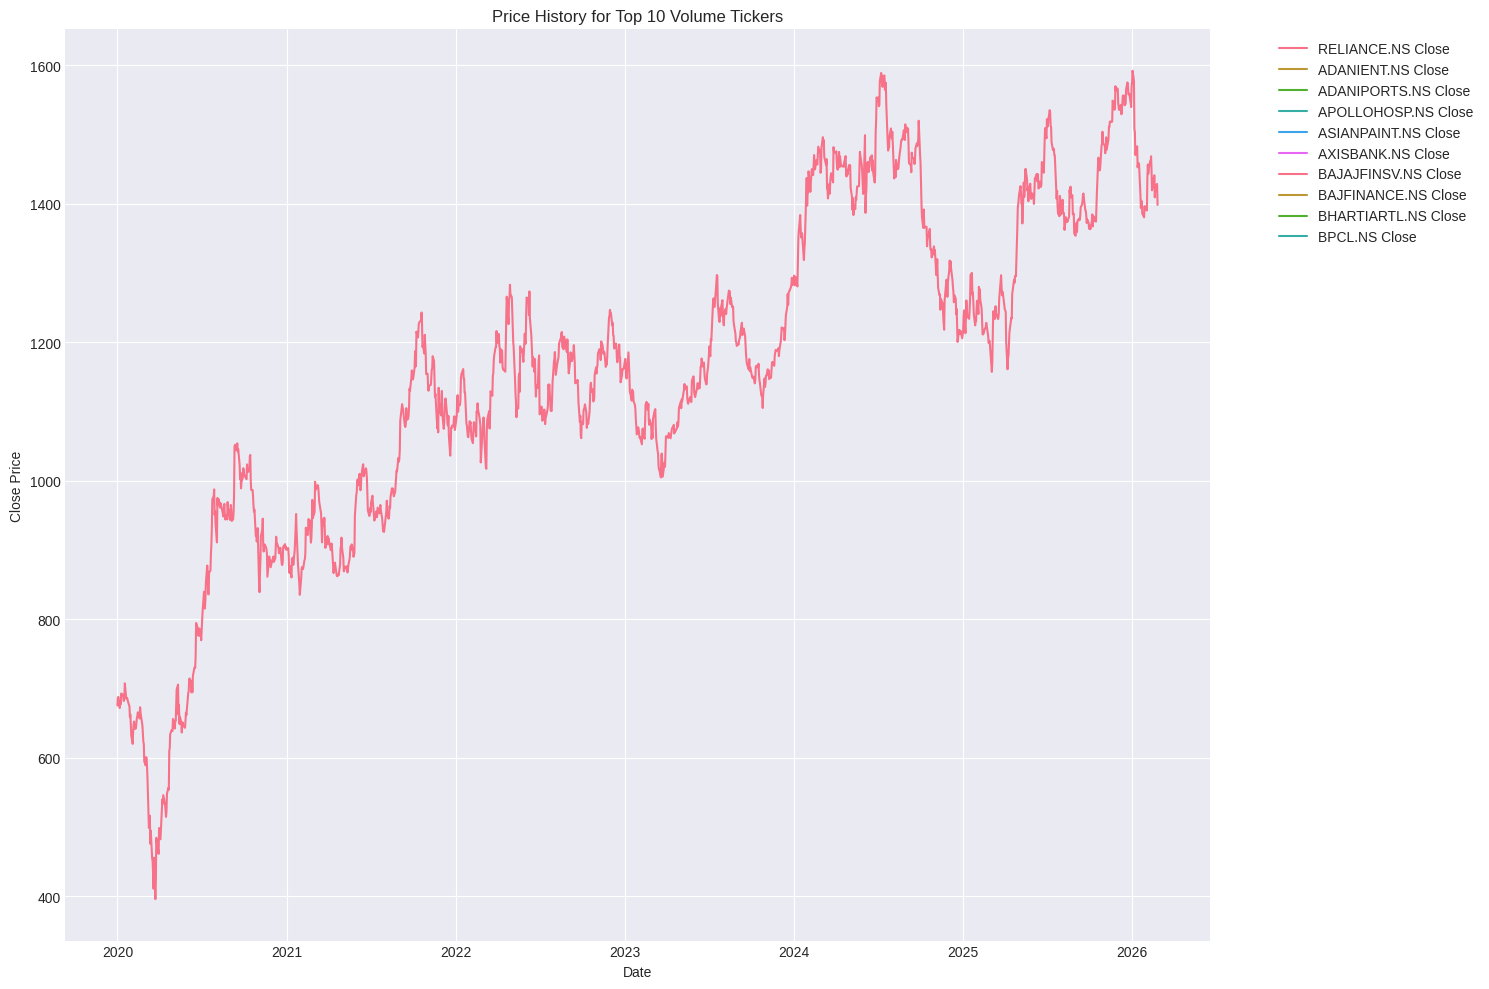

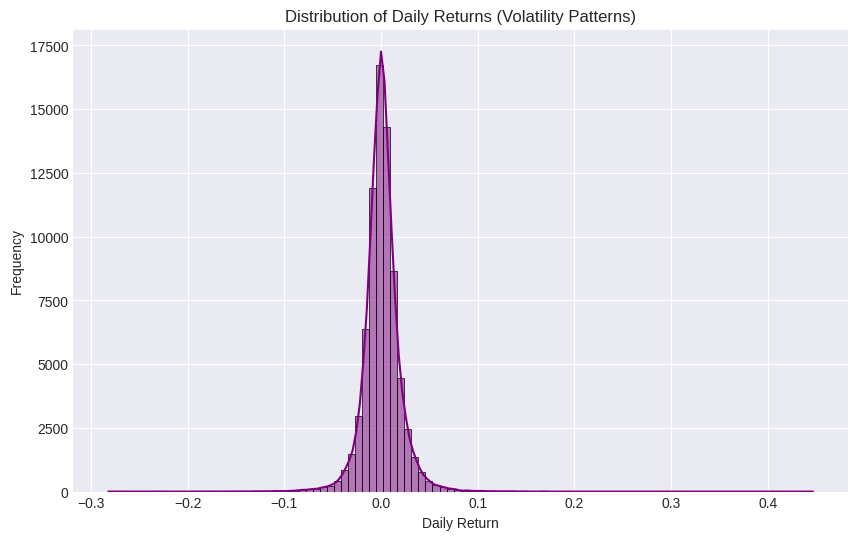

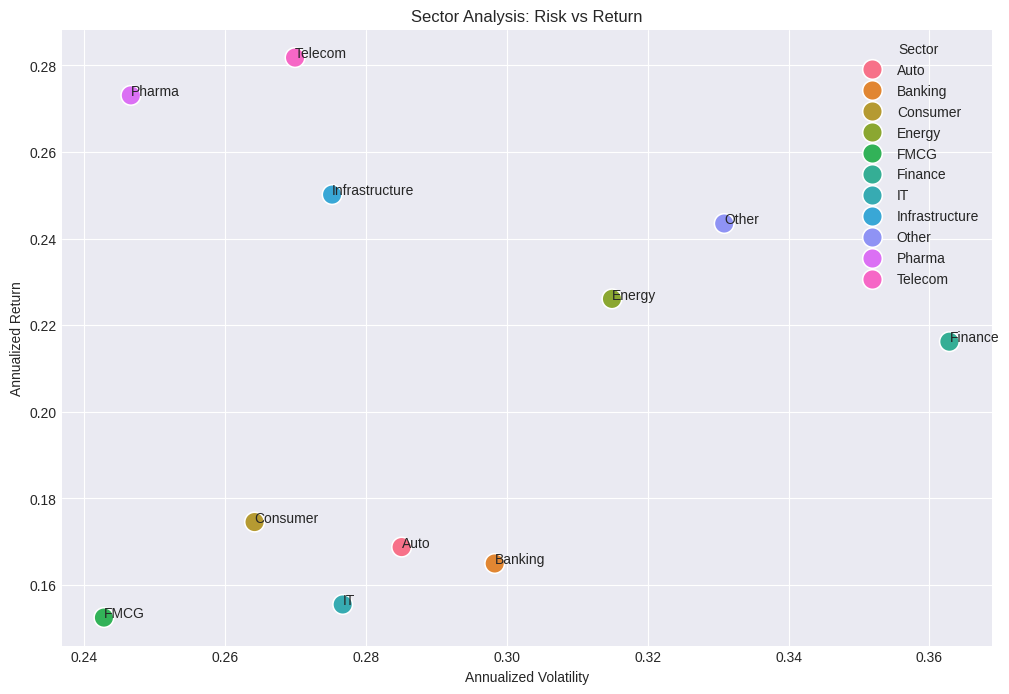

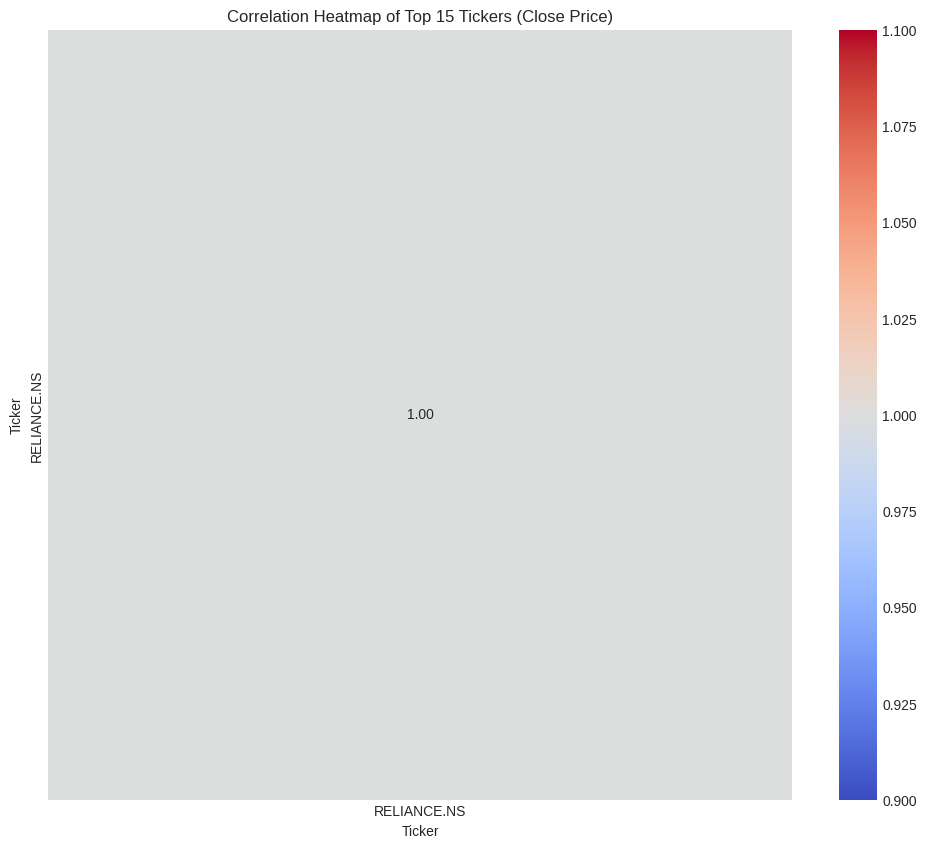

EDA charts successfully saved in charts/eda


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the cleaned master dataset
file_path = 'data/nifty50_master_combined.csv'
df_master = pd.read_csv(file_path, parse_dates=['Date'])

# 2. Create directory for EDA charts
output_dir = 'charts/eda'
os.makedirs(output_dir, exist_ok=True)

# Define Sector Map (as provided in the project context)
SECTOR_MAP = {
    'RELIANCE.NS': 'Energy', 'ONGC.NS': 'Energy', 'IOC.NS': 'Energy', 'BPCL.NS': 'Energy', 'COALINDIA.NS': 'Energy',
    'TCS.NS': 'IT', 'INFY.NS': 'IT', 'HCLTECH.NS': 'IT', 'WIPRO.NS': 'IT', 'TECHM.NS': 'IT',
    'HDFCBANK.NS': 'Banking', 'ICICIBANK.NS': 'Banking', 'SBIN.NS': 'Banking', 'KOTAKBANK.NS': 'Banking', 'AXISBANK.NS': 'Banking',
    'HINDUNILVR.NS': 'FMCG', 'ITC.NS': 'FMCG', 'NESTLEIND.NS': 'FMCG', 'TATACONSUM.NS': 'FMCG', 'BRITANNIA.NS': 'FMCG',
    'BHARTIARTL.NS': 'Telecom', 'LT.NS': 'Infrastructure', 'MARUTI.NS': 'Auto', 'TATAMOTORS.NS': 'Auto',
    'SUNPHARMA.NS': 'Pharma', 'BAJFINANCE.NS': 'Finance', 'ASIANPAINT.NS': 'Consumer', 'TITAN.NS': 'Consumer'
}
df_master['Sector'] = df_master['Ticker'].map(SECTOR_MAP).fillna('Other')

# 3. Price History for top 10 tickers by Volume
top_10_vol = df_master.groupby('Ticker')['Volume'].mean().sort_values(ascending=False).head(10).index
plt.figure(figsize=(15, 10))
for ticker in top_10_vol:
    data = df_master[df_master['Ticker'] == ticker].sort_values('Date')
    plt.plot(data['Date'], data['Close'], label=f'{ticker} Close')
plt.title('Price History for Top 10 Volume Tickers')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_dir}/01_price_history.png')
plt.show()

# 4. Distribution of Daily Returns
plt.figure(figsize=(10, 6))
sns.histplot(df_master['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Returns (Volatility Patterns)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.savefig(f'{output_dir}/02_returns_distribution.png')
plt.show()

# 5. Sector Risk vs Return
sector_stats = df_master.groupby('Sector')['Daily_Return'].agg(['mean', 'std'])
sector_stats['Annual_Return'] = sector_stats['mean'] * 252
sector_stats['Annual_Volatility'] = sector_stats['std'] * np.sqrt(252)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=sector_stats, x='Annual_Volatility', y='Annual_Return', hue='Sector', s=200)
for i in range(sector_stats.shape[0]):
    plt.text(sector_stats.Annual_Volatility[i], sector_stats.Annual_Return[i], sector_stats.index[i])
plt.title('Sector Analysis: Risk vs Return')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.grid(True)
plt.savefig(f'{output_dir}/03_sector_risk_return.png')
plt.show()

# 6. Correlation Heatmap for Top 15 Tickers
top_15_tickers = df_master.groupby('Ticker')['Close'].mean().sort_values(ascending=False).head(15).index
corr_df = df_master[df_master['Ticker'].isin(top_15_tickers)].pivot_table(index='Date', columns='Ticker', values='Close').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top 15 Tickers (Close Price)')
plt.savefig(f'{output_dir}/04_correlation_heatmap.png')
plt.show()

print(f"EDA charts successfully saved in {output_dir}")

**Reasoning**:
The previous EDA code missed including the 20-day and 50-day moving averages in the price history plot as requested. I will regenerate the EDA charts, specifically adding the SMA indicators to the price history plot for the top 10 tickers.



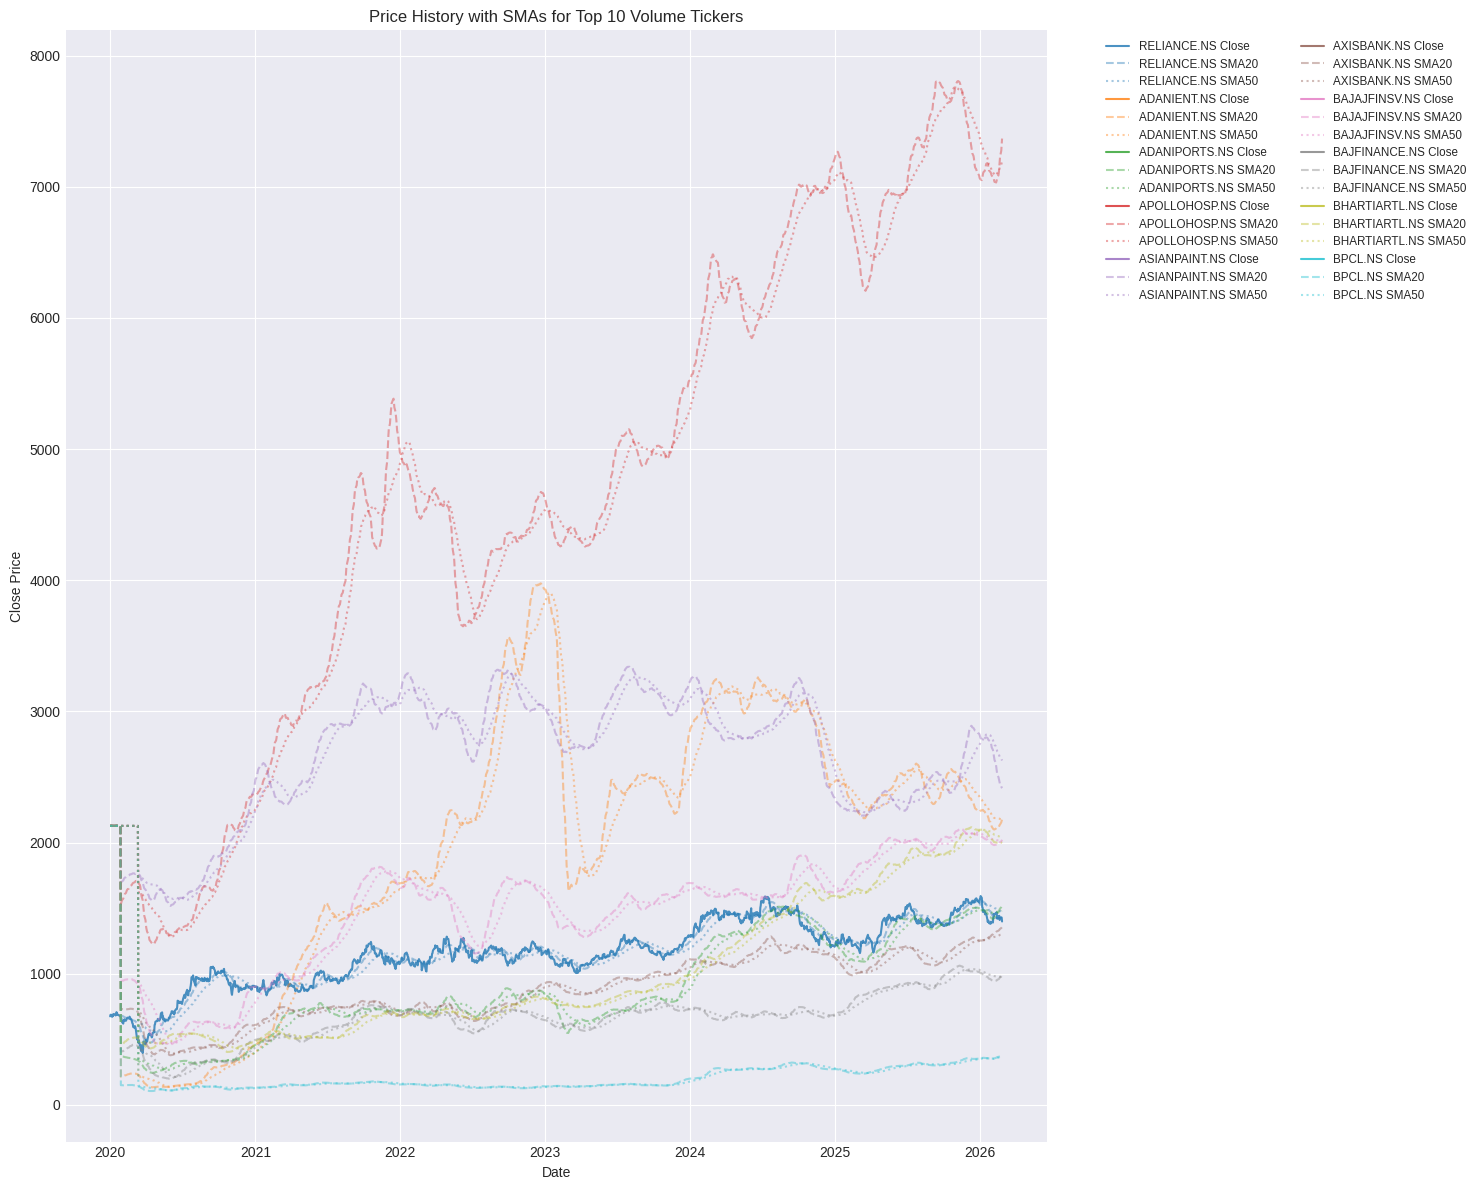

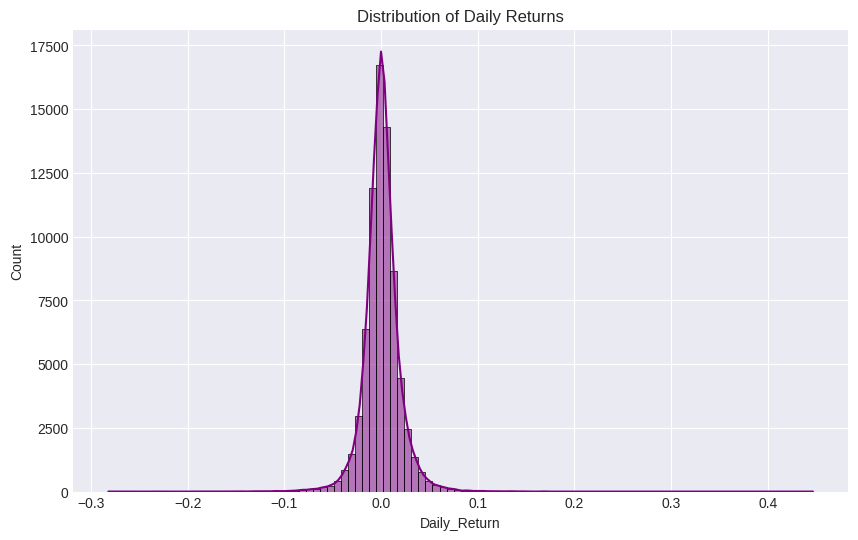

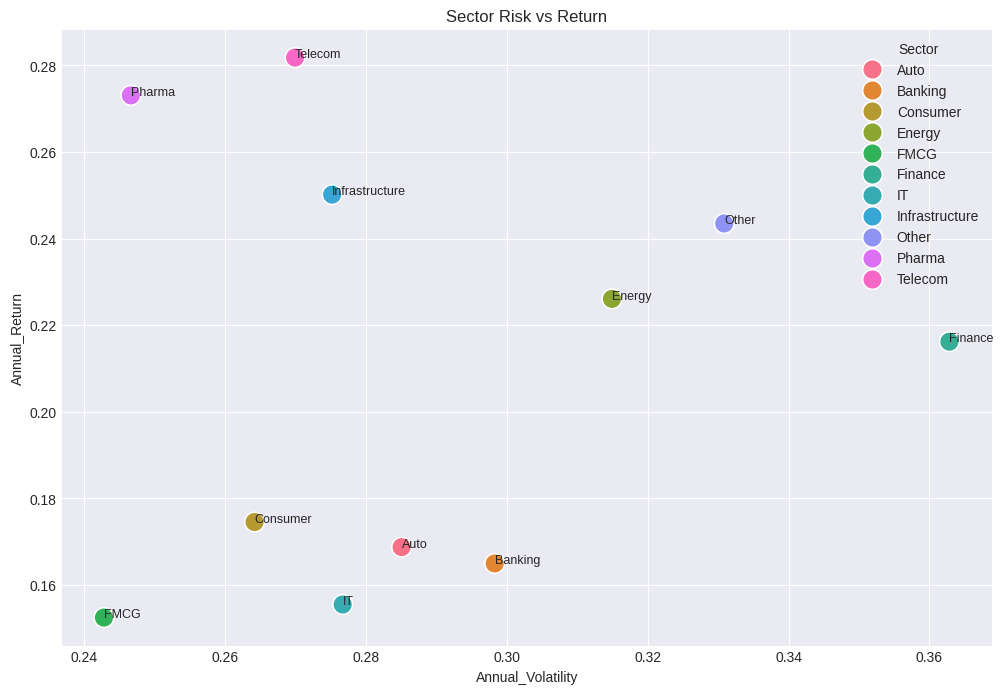

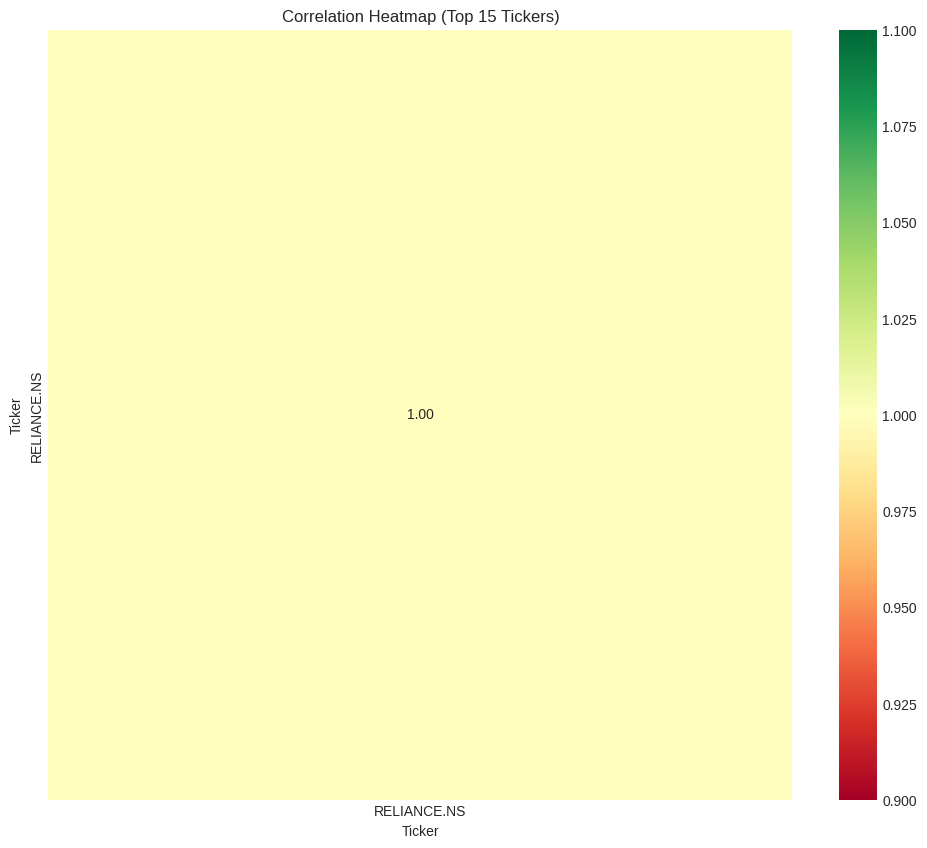

Updated EDA charts saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df_master = pd.read_csv('data/nifty50_master_combined.csv', parse_dates=['Date'])
output_dir = 'charts/eda'
os.makedirs(output_dir, exist_ok=True)

SECTOR_MAP = {
    'RELIANCE.NS': 'Energy', 'ONGC.NS': 'Energy', 'IOC.NS': 'Energy', 'BPCL.NS': 'Energy', 'COALINDIA.NS': 'Energy',
    'TCS.NS': 'IT', 'INFY.NS': 'IT', 'HCLTECH.NS': 'IT', 'WIPRO.NS': 'IT', 'TECHM.NS': 'IT',
    'HDFCBANK.NS': 'Banking', 'ICICIBANK.NS': 'Banking', 'SBIN.NS': 'Banking', 'KOTAKBANK.NS': 'Banking', 'AXISBANK.NS': 'Banking',
    'HINDUNILVR.NS': 'FMCG', 'ITC.NS': 'FMCG', 'NESTLEIND.NS': 'FMCG', 'TATACONSUM.NS': 'FMCG', 'BRITANNIA.NS': 'FMCG',
    'BHARTIARTL.NS': 'Telecom', 'LT.NS': 'Infrastructure', 'MARUTI.NS': 'Auto', 'TATAMOTORS.NS': 'Auto',
    'SUNPHARMA.NS': 'Pharma', 'BAJFINANCE.NS': 'Finance', 'ASIANPAINT.NS': 'Consumer', 'TITAN.NS': 'Consumer'
}
df_master['Sector'] = df_master['Ticker'].map(SECTOR_MAP).fillna('Other')

top_10_vol = df_master.groupby('Ticker')['Volume'].mean().sort_values(ascending=False).head(10).index
plt.figure(figsize=(15, 12))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, ticker in enumerate(top_10_vol):
    data = df_master[df_master['Ticker'] == ticker].sort_values('Date')
    plt.plot(data['Date'], data['Close'], label=f'{ticker} Close', color=colors[i], alpha=0.8)
    if 'MA_20' in data.columns:
        plt.plot(data['Date'], data['MA_20'], linestyle='--', color=colors[i], alpha=0.4, label=f'{ticker} SMA20')
    if 'MA_50' in data.columns:
        plt.plot(data['Date'], data['MA_50'], linestyle=':', color=colors[i], alpha=0.4, label=f'{ticker} SMA50')

plt.title('Price History with SMAs for Top 10 Volume Tickers')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout()
plt.savefig(f'{output_dir}/01_price_history_sma.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_master['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Returns')
plt.savefig(f'{output_dir}/02_returns_distribution.png')
plt.show()

sector_stats = df_master.groupby('Sector')['Daily_Return'].agg(['mean', 'std'])
sector_stats['Annual_Return'] = sector_stats['mean'] * 252
sector_stats['Annual_Volatility'] = sector_stats['std'] * np.sqrt(252)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=sector_stats, x='Annual_Volatility', y='Annual_Return', hue='Sector', s=200)
for i in range(sector_stats.shape[0]):
    plt.text(sector_stats.Annual_Volatility[i], sector_stats.Annual_Return[i], sector_stats.index[i], fontsize=9)
plt.title('Sector Risk vs Return')
plt.savefig(f'{output_dir}/03_sector_risk_return.png')
plt.show()

top_15_tickers = df_master.groupby('Ticker')['Close'].mean().sort_values(ascending=False).head(15).index
corr_df = df_master[df_master['Ticker'].isin(top_15_tickers)].pivot_table(index='Date', columns='Ticker', values='Close').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap (Top 15 Tickers)')
plt.savefig(f'{output_dir}/04_correlation_heatmap.png')
plt.show()

print("Updated EDA charts saved successfully.")

## Run Scoring and Predictions

### Subtask:
Execute the multi-factor stock scoring model and machine learning price prediction models on the combined master dataset.


**Reasoning**:
I will load the cleaned master dataset and implement the multi-factor scoring model to rank stocks, then prepare the machine learning pipeline with ensemble models and feature engineering for price forecasting.



In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from datetime import timedelta

# 1. Load the cleaned master dataset
df_master = pd.read_csv('data/nifty50_master_combined.csv', parse_dates=['Date'])
os.makedirs('charts/predictions', exist_ok=True)
os.makedirs('data', exist_ok=True)

# 2. Multi-factor Stock Scoring
def compute_scores(df):
    records = []
    for ticker, sub in df.groupby('Ticker'):
        sub = sub.sort_values('Date')
        close = sub['Close'].dropna()
        if len(close) < 252: continue

        # Momentum
        ret_1y = (close.iloc[-1] / close.iloc[-252] - 1)
        ret_6m = (close.iloc[-1] / close.iloc[-126] - 1) if len(close) >= 126 else ret_1y
        momentum = np.nanmean([ret_1y, ret_6m])

        # Sharpe & Volatility
        daily_ret = close.pct_change().dropna()
        sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252) if daily_ret.std() > 0 else 0
        vol_20 = daily_ret.tail(20).std() * np.sqrt(252)

        records.append({'Ticker': ticker, 'Last_Price': close.iloc[-1], 'Momentum': momentum, 'Sharpe': sharpe, 'Volatility': vol_20})

    scores_df = pd.DataFrame(records)
    if scores_df.empty: return pd.DataFrame()
    scores_df['S_Momentum'] = scores_df['Momentum'].rank(pct=True) * 100
    scores_df['S_Sharpe'] = scores_df['Sharpe'].rank(pct=True) * 100
    scores_df['S_Vol'] = scores_df['Volatility'].rank(ascending=False, pct=True) * 100
    scores_df['Composite_Score'] = (scores_df['S_Momentum'] * 0.4 + scores_df['S_Sharpe'] * 0.4 + scores_df['S_Vol'] * 0.2).round(2)
    return scores_df.sort_values('Composite_Score', ascending=False)

# 3. ML Pipeline with Feature Engineering
def predict_90d(ticker_df, forecast_days=90):
    df = ticker_df.copy().sort_values('Date')

    df['MA_20'] = df['Close'].rolling(20).mean()
    df['MA_50'] = df['Close'].rolling(50).mean()
    for l in [1, 2, 3, 5]: df[f'Lag_{l}'] = df['Close'].shift(l)

    df['Target'] = df['Close'].shift(-1)
    df = df.dropna(subset=['Target', 'MA_50', 'Lag_5'])

    if len(df) < 100: return None, None, None

    features = ['MA_20', 'MA_50', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5']
    X, y = df[features], df['Target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
    gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)

    future_preds = []
    curr_feat = X.iloc[[-1]].values
    for _ in range(forecast_days):
        p = (rf.predict(curr_feat)[0] + gb.predict(curr_feat)[0]) / 2
        future_preds.append(p)
        new_feat = curr_feat.copy()
        new_feat[0, 2:] = np.roll(new_feat[0, 2:], 1); new_feat[0, 2] = p
        curr_feat = new_feat

    return future_preds, df['Date'].iloc[-1], y_test.std()

# 4. Execute for Top 10
scores_df = compute_scores(df_master)
pred_summary = []
if not scores_df.empty:
    top_tickers = scores_df.head(10)['Ticker'].tolist()
    for ticker in top_tickers:
        sub = df_master[df_master['Ticker'] == ticker]
        preds, last_date, rmse = predict_90d(sub)
        if preds:
            future_dates = [last_date + timedelta(days=i) for i in range(1, 91)]
            plt.figure(figsize=(10, 4))
            plt.plot(sub['Date'].tail(60), sub['Close'].tail(60), label='Actual')
            plt.plot(future_dates, preds, '--', label='Forecast')
            plt.title(f'90-Day ML Price Forecast: {ticker}')
            plt.legend(); plt.savefig(f'charts/predictions/predict_{ticker}.png'); plt.close()
            pred_summary.append({'Ticker': ticker, 'Current': sub['Close'].iloc[-1], 'Target_90D': round(preds[-1], 2), 'Expected_Return_%': round(((preds[-1]/sub['Close'].iloc[-1])-1)*100, 2)})

if pred_summary:
    pd.DataFrame(pred_summary).to_csv('data/predictions_summary.csv', index=False)
    print('✅ Predictions generated and saved.')
    display(pd.DataFrame(pred_summary))
else:
    print('⚠ No predictions could be generated with available data.')

✅ Predictions generated and saved.


,Ticker,Current,Target_90D,Expected_Return_%
0,RELIANCE.NS,1398.5,1451.6,3.8


In [ ]:
import os
from IPython.display import Image, display

chart_dir = 'charts/predictions/'
if os.path.exists(chart_dir):
    files = [f for f in os.listdir(chart_dir) if f.endswith('.png')]
    if files:
        print(f'Found {len(files)} prediction charts:')
        for file in sorted(files):
            print(f'\n--- {file} ---')
            display(Image(filename=os.path.join(chart_dir, file)))
    else:
        print('No PNG charts found in the predictions directory.')
else:
    print(f'Directory {chart_dir} does not exist. Please run the prediction cell first.')

No PNG charts found in the predictions directory.
